# Analyst- Adarsh Singh

# Project : RETAIL SALES PREDICTION

## Problem statement: 
*The aim of the Retail Sales Project is to analyze and predict retail sales trends. This involves working with datasets that include features like store details, sales data, and external factors such as temperature and unemployment rates. The goal is likely to develop a model that can forecast sales, helping businesses optimize inventory and improve decision-making.*

## Importing Libraries 
*These libraries collectively equip us with tools for data preparation, analysis, and visualization, which are essential for building accurate predictive models for the project.*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [2]:
df_1 = pd.read_csv('features.csv.xls')

In [3]:
df_2 = pd.read_csv('stores.csv.xls')
df_3 = pd.read_csv('train.csv.xls')

In [4]:
df_1.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [5]:
df_2.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [6]:
df_3.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


### Merging Dataframes to form one Dataframe.

In [7]:
first = pd.merge(left=df_3, right=df_2, how='left', on='Store')

In [8]:
df = pd.merge(left=first, right=df_1, how='left', on=['Store','Date','IsHoliday']) 

In [9]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667


## Descriptive Analysis of Dataset

### Summary statistics of tha data:

In [10]:
df.describe()

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,136727.915739,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289
std,12.785297,30.492054,22711.183519,60980.583328,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296
min,1.000000,1.000000,-4988.940000,34875.000000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000
25%,11.000000,18.000000,2079.650000,93638.000000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000
50%,22.000000,37.000000,7612.030000,140167.000000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000
75%,33.000000,74.000000,20205.852500,202505.000000,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000
max,45.000000,99.000000,693099.360000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000


### Data types and missing values:

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Type          421570 non-null  object 
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     150681 non-null  float64
 10  MarkDown2     111248 non-null  float64
 11  MarkDown3     137091 non-null  float64
 12  MarkDown4     134967 non-null  float64
 13  MarkDown5     151432 non-null  float64
 14  CPI           421570 non-null  float64
 15  Unemployment  421570 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [12]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64

*so as we seen there are so much null values in Markdown columns...so first we visualize it to understand patterns and then we work on it..*

## Visualization of Data

#### Datetime Format
*To convert the 'Date' column in our DataFrame into a datetime format. This is essential for handling and analyzing date-related data effectively.*

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
sales = df.groupby('Date')['Weekly_Sales'].sum()

In [15]:
sales

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
                 ...     
2012-09-28    43734899.40
2012-10-05    47566639.31
2012-10-12    46128514.25
2012-10-19    45122410.57
2012-10-26    45544116.29
Name: Weekly_Sales, Length: 143, dtype: float64

**To calculate the total weekly sales for each date.**

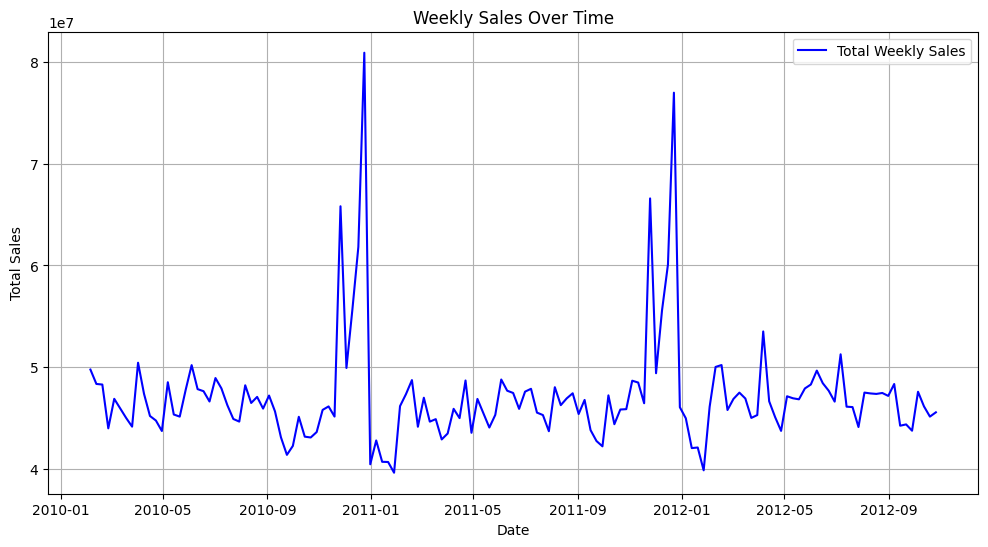

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(sales, label='Total Weekly Sales', color='blue')
plt.title('Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid()
plt.show()

**Line plot that visualizes the trend of total weekly sales over time to identify patterns, such as seasonal peaks or dips in sales.**

#### There are three very noticeable sales spikes:

***Around late December 2010, December 2011, and late 2012.***


***These are most likely due to holiday season sales.***

***Sales mostly stay between 14,000 to 17,000, showing a fairly stable base level.***

In [17]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()

**calculates the average weekly sales for holiday and non-holiday periods.**

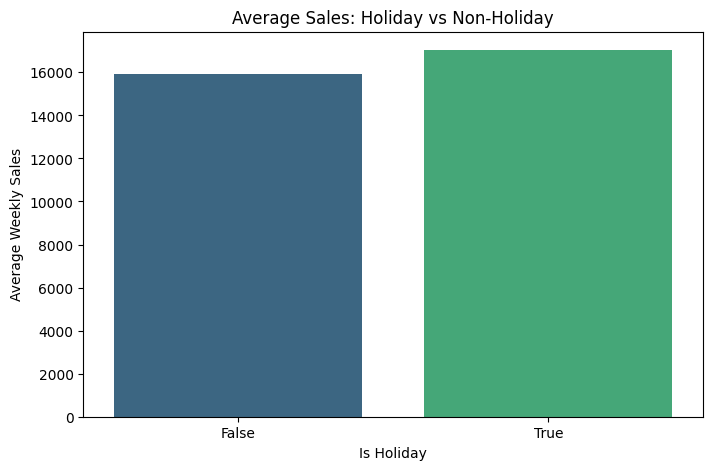

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(x=holiday_sales.index, y=holiday_sales.values, palette='viridis')
plt.title('Average Sales: Holiday vs Non-Holiday')
plt.xlabel('Is Holiday')
plt.ylabel('Average Weekly Sales')
plt.show()

***By observing the bar heights, we can quickly identify whether holidays significantly boost sales.***

***In this...we can clearly see that there is not that much difference...so we can say holiday doesn't affect sales so much.***

In [19]:
store_performance = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

***calculates the total weekly sales for each store and sorts them in descending order.***

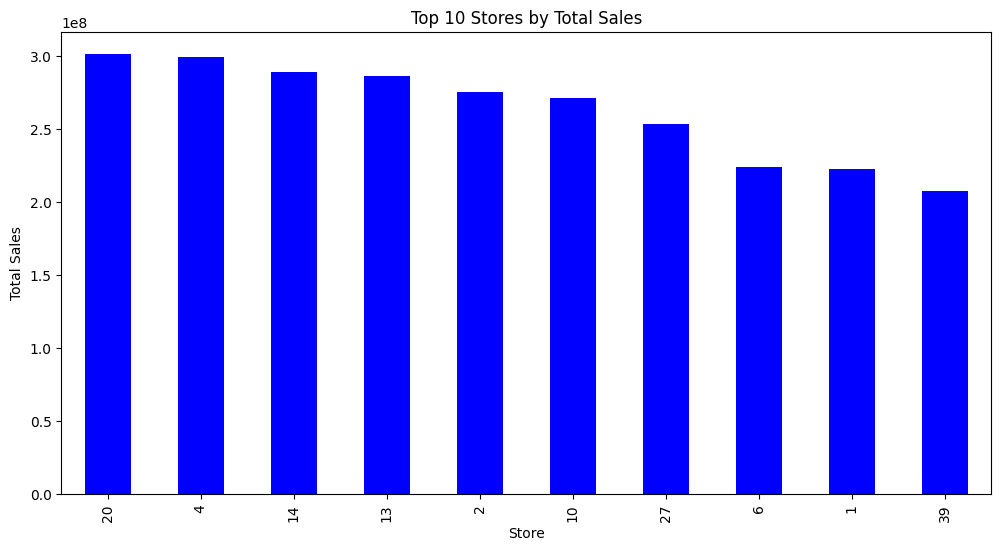

In [20]:
plt.figure(figsize=(12, 6))
store_performance.head(10).plot(kind='bar', color='blue', title='Top 10 Stores by Total Sales')
plt.ylabel('Total Sales')
plt.show()

***This plot highlights which stores are the most successful in terms of revenue, allowing to identify key contributors to overall sales***

***In above graph we can see that Store 20 and 4 are the most successful in terms of revenue...and followed by Store 13 and 14***

In [21]:
dept_performance = df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)

***calculates the total weekly sales for each department and sorts them in descending order.***

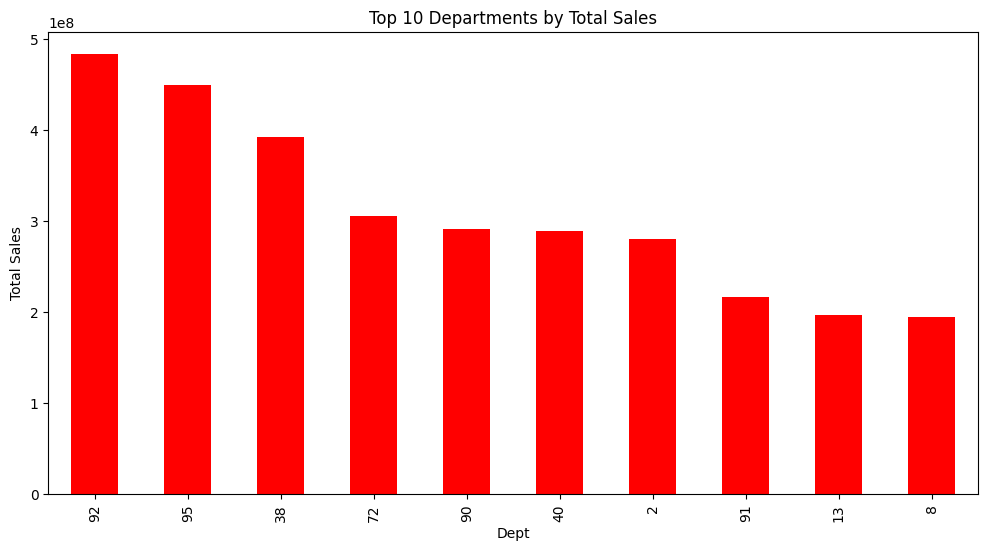

In [22]:
plt.figure(figsize=(12, 6))
dept_performance.head(10).plot(kind='bar', color='red', title='Top 10 Departments by Total Sales')
plt.ylabel('Total Sales')
plt.show()

***This Graph highlights which departments are the most profitable, showcasing their contribution to overall revenue.***

***In graph we can see that Departments 92 and 95 are the most profitable.***

***Whereas Department 13 and 8 are extremely less profitable.***

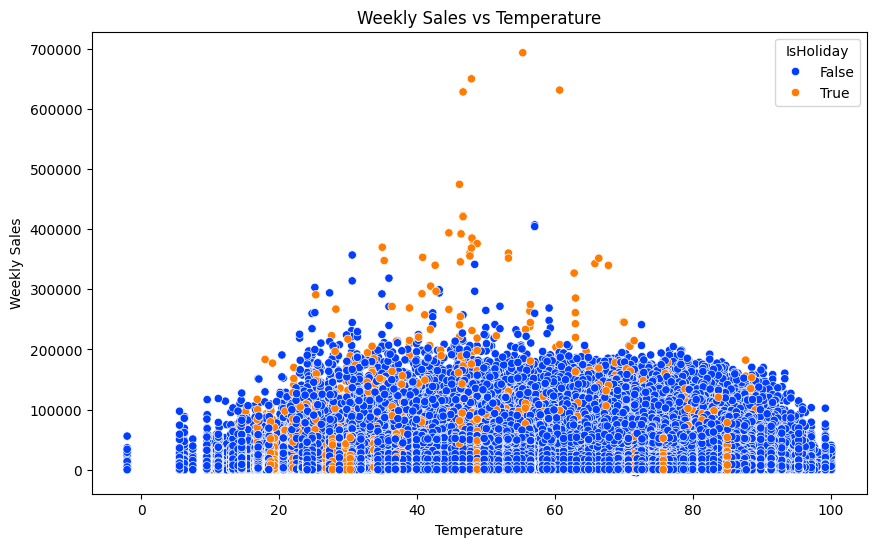

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, hue='IsHoliday', palette='bright')
plt.title('Weekly Sales vs Temperature')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.show()

**This scatter plot is used to visualize the relationship between temperature and weekly sales with holidays highlighted using 2 different colors.**

***These data points shows higher weekly sales..indicating that holidays positively impact sales.***

***And during Non-Holidays graph shows lower weekly sales***

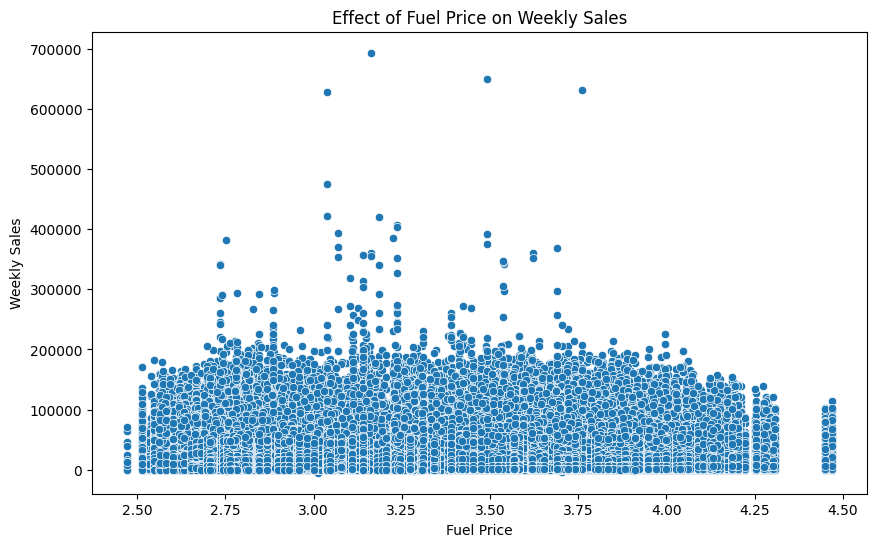

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df)
plt.title('Effect of Fuel Price on Weekly Sales')
plt.xlabel('Fuel Price')
plt.ylabel('Weekly Sales')
plt.show()

**This scatter plot reveals the relationship between fuel price and weekly sales.After observing this graph we get to know that :-**

***The fuel price ranges roughly between $2.5 and $4.5.***

***Most weekly sales fall between 0 to 300,000, with a few outliers going as high as 600K–700K.***

***As fuel price increases (especially after $3.5), there seems to be a slight decline in weekly sales.***

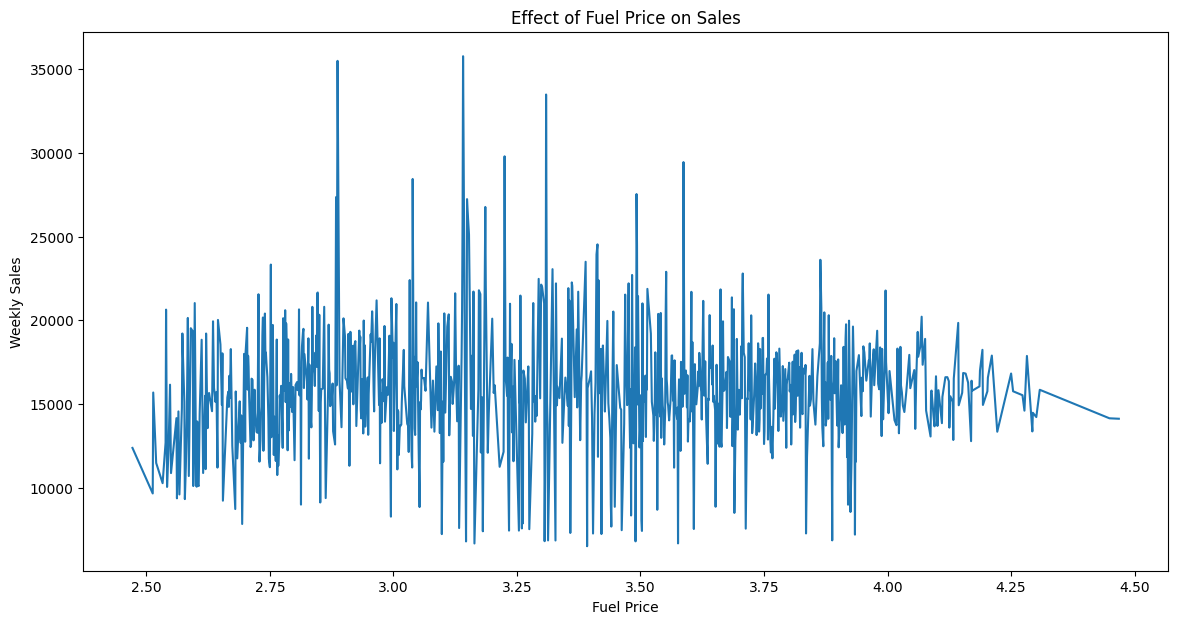

In [25]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='Fuel_Price', y='Weekly_Sales', data=df, ci=None)
plt.title('Effect of Fuel Price on Sales')
plt.xlabel('Fuel Price')
plt.ylabel('Weekly Sales')
plt.show()

**This Line plot shows how weekly sales vary as fuel prices change, helping to identify any consistent trends or patterns.**

***The plot does not suggest a strong or smooth relationship between fuel price and weekly sales.***

***As fuel prices rise above $4.0, weekly sales show a slight downward trend and become less volatile.***

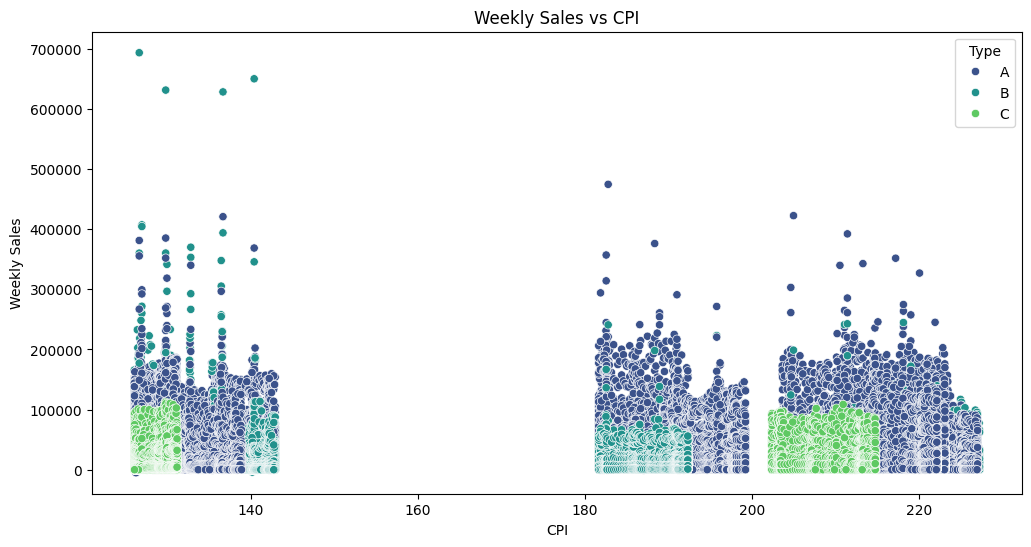

In [26]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='CPI', y='Weekly_Sales', data=df, hue='Type', palette='viridis')
plt.title('Weekly Sales vs CPI')
plt.xlabel('CPI')
plt.ylabel('Weekly Sales')
plt.show()

**In this Scatter plot ...by using different colors for store types...we can observe how sales trends vary across different store categories**

***There are two major clusters of CPI values:***
***Around 130 to 145***
***Around 180 to 225***

***Type A appears to have the highest range of weekly sales touching 700,000+.Type B and C mostly stay below 200,000***

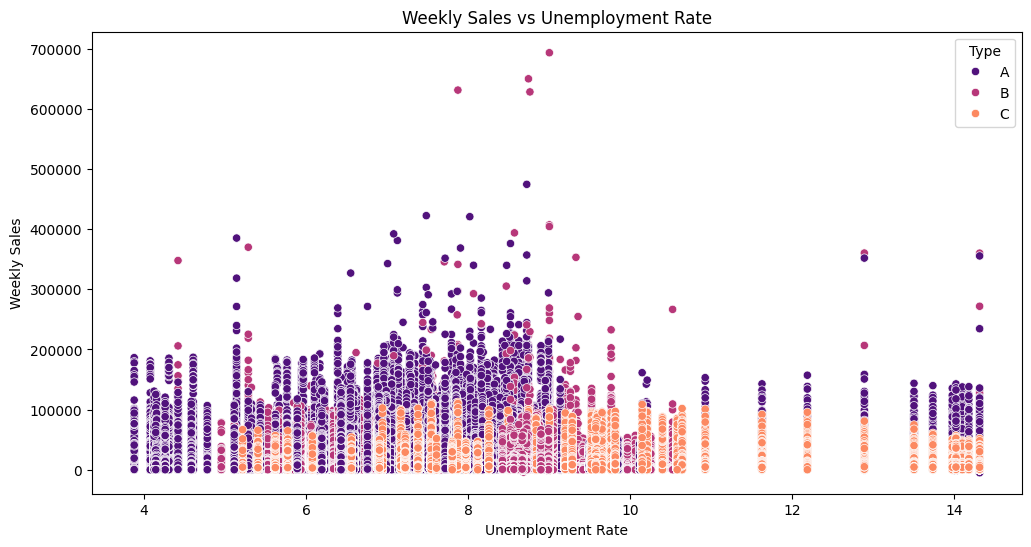

In [27]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df, hue='Type', palette='magma')
plt.title('Weekly Sales vs Unemployment Rate')
plt.xlabel('Unemployment Rate')
plt.ylabel('Weekly Sales')
plt.show()

***In this plot...we using colors to represent store types so that we can observe how sales trends vary across different store categories.***


***So as we seen in the graph...Majority of data is concentrated between 4% to 10% unemployment rate.***

***Type A has the highest weekly sales even beyond 700,000.***

***Type B moderate performance..usually under 300,000.***

***Type C lowest performance..usually under 100,000***

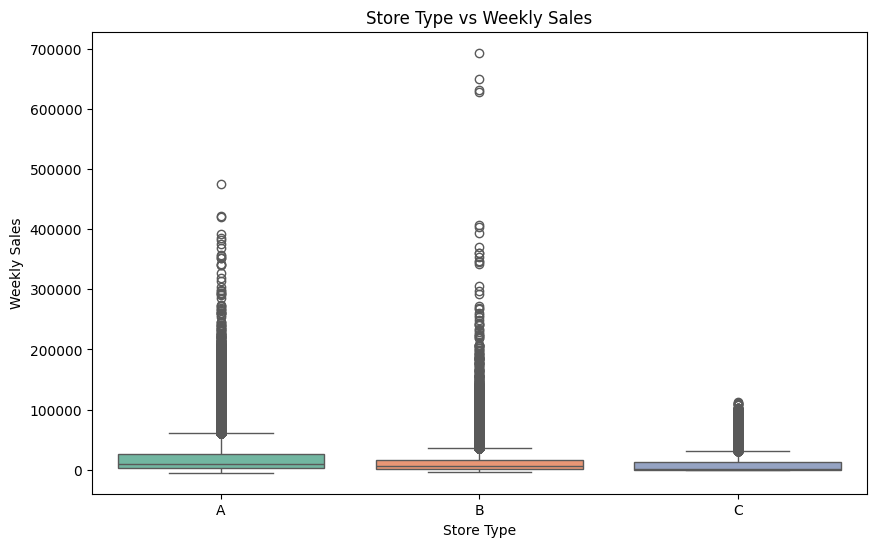

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Weekly_Sales', data=df, palette='Set2')
plt.title('Store Type vs Weekly Sales')
plt.xlabel('Store Type')
plt.ylabel('Weekly Sales')
plt.show()

***By using BOX PlOT we can identify which store type consistently performs better or has more variability and outliers in sales.***

## Measure of central Tendency and Dispersion

In [29]:
group_stats = df.groupby('Type')['Weekly_Sales'].agg(['mean', 'median', 'std', 'min', 'max'])
group_stats

,mean,median,std,min,max
Type,,,,,
A,20099.568043,10105.17,26423.457227,-4988.94,474330.10
B,12237.075977,6187.87,17203.668989,-3924.00,693099.36
C,9519.532538,1149.67,15985.351612,-379.00,112152.35


#### Output we get from above Table ####
***Mean: Store Type A has the highest average sales 20,099.57 than B and C***\n

***Median: Store Type A still leads here... but the median is smaller than its mean.***

***Standard Deviation :  Type A exhibits the most variability 26,423.46, implying diverse sales performance whereas Type C shows the least variability.***

***Min & Max: Type B has the highest maximum sales 693,099.36, while Type A has the most extreme minimum -4,988.94.***

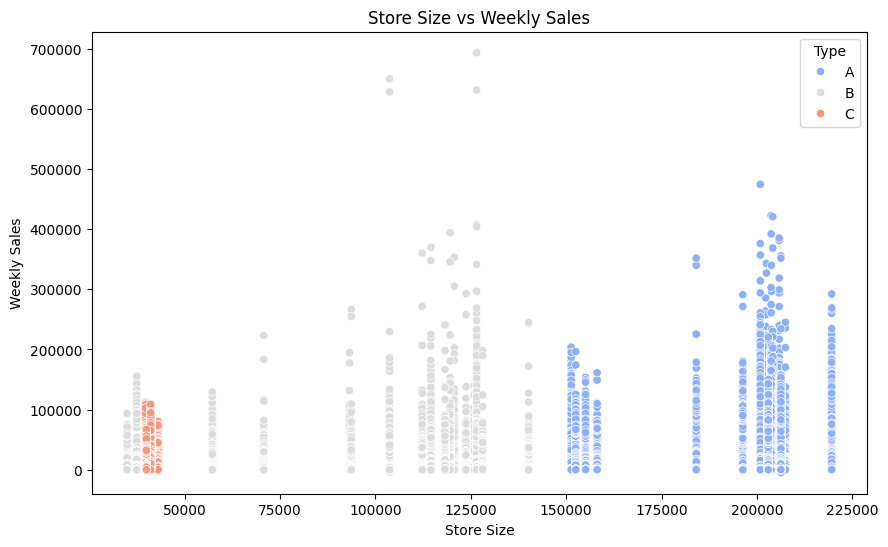

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size', y='Weekly_Sales', data=df, hue='Type', palette='coolwarm')
plt.title('Store Size vs Weekly Sales')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')
plt.show()

### In above graph
***Type A shows consistent high sales across large store sizes.***

***Type B has scattered sales..indicating inconsistent performance.***

***Type C is clustered at low size and low sales...and showing consistently low performance.***

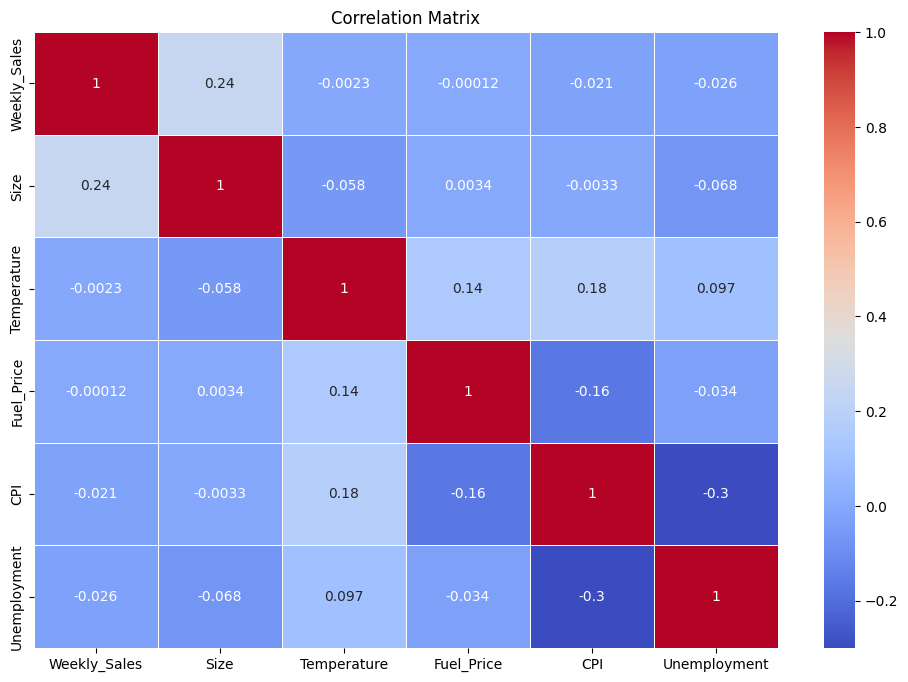

In [31]:
plt.figure(figsize=(12, 8))
corr = df[['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

***Size column has a moderate positive correlation (correlation value of 0.24) with Weekly_Sales. That indicates that larger store sizes are associated with higher weekly sales... but the relationship isn't very strong.***

***Temperature, Fuel_Price, CPI and Unemployment have very weak correlations with Weekly_Sales***

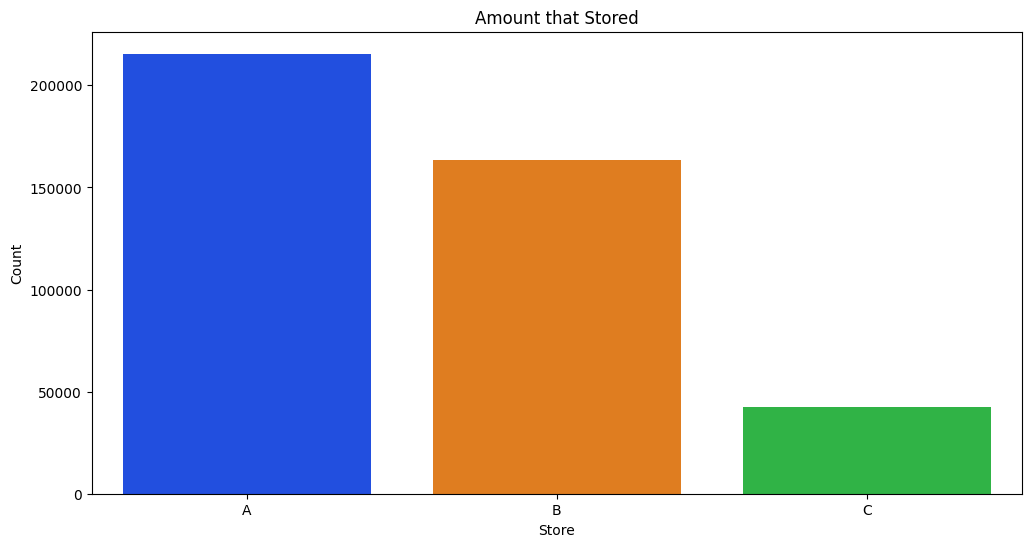

In [32]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Type', hue="Type",palette='bright')
plt.title('Amount that Stored')
plt.xlabel('Store')
plt.ylabel('Count')
plt.show()

***Type A stores have the largest store sizes(approx 22000).***

***Type B stores are of medium size( nearly 16000) and larger than Type C.***

***Type C stores are smallest in size and show the lowest sales.***


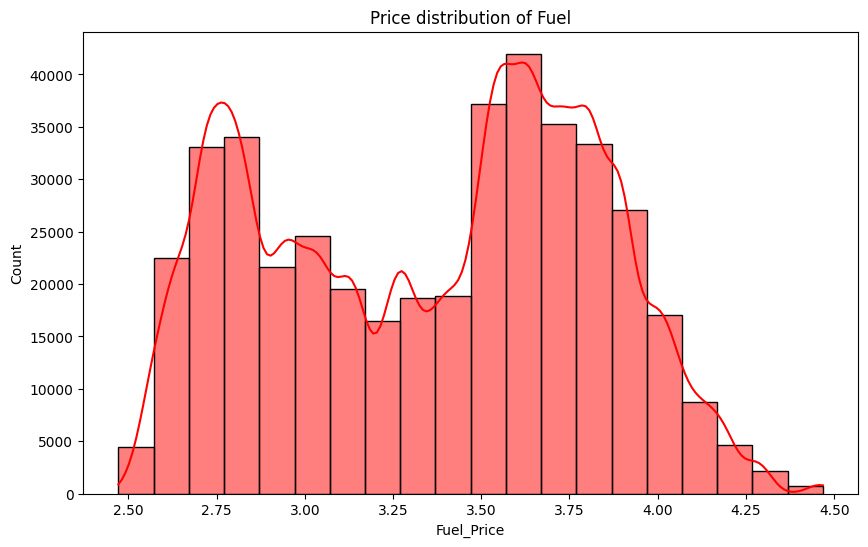

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Fuel_Price', bins=20, kde=True, color='red')
plt.title('Price distribution of Fuel')
plt.xlabel('Fuel_Price')
plt.ylabel('Count')
plt.show()

***The graph has two clear peaks...in which one is around  2.75–2.85  and the other is around  $3.55–3.65.***

***This means fuel prices were most commonly in these two ranges — there were two separate time periods or zones where prices clustered.***

In [34]:
df['Date'] = pd.to_datetime(df['Date'])

In [35]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

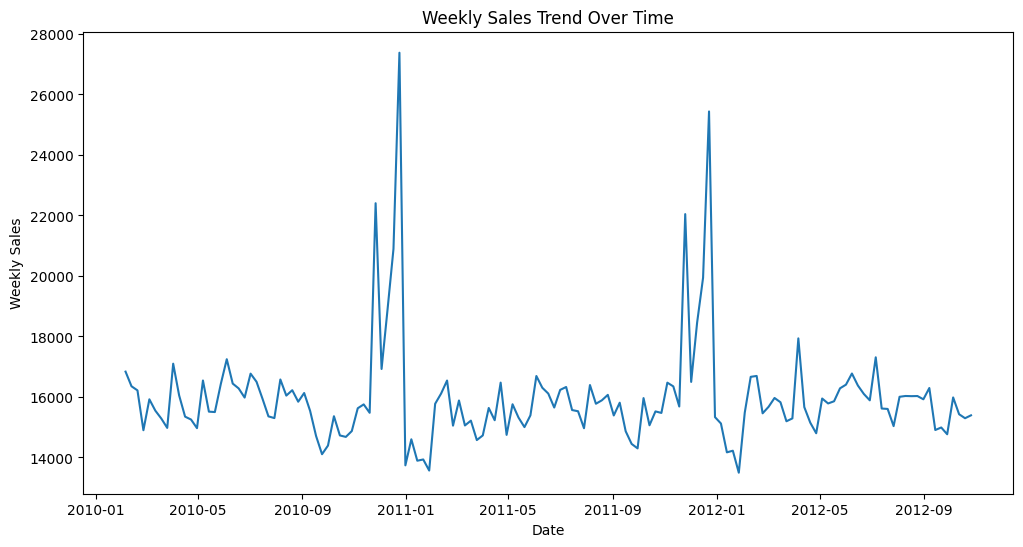

In [36]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Weekly_Sales', ci=None)
plt.title('Weekly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()

#### There are three very noticeable sales spikes:

***Around late December 2010, December 2011, and late 2012.***


***These are most likely due to holiday season sales.***

***Sales mostly stay between 14,000 to 17,000, showing a fairly stable base level.***

In [37]:
df.dropna()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
92,1,1,2011-11-11,18689.54,False,A,151315,59.11,3.297,10382.90,6115.67,215.07,2406.62,6551.42,217.998085,7.866,2011,11
93,1,1,2011-11-18,19050.66,False,A,151315,62.25,3.308,6074.12,254.39,51.98,427.39,5988.57,218.220509,7.866,2011,11
94,1,1,2011-11-25,20911.25,True,A,151315,60.14,3.236,410.31,98.00,55805.51,8.00,554.92,218.467621,7.866,2011,11
95,1,1,2011-12-02,25293.49,False,A,151315,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866,2011,12
96,1,1,2011-12-09,33305.92,False,A,151315,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866,2011,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421561,45,98,2012-08-31,346.04,False,B,118221,75.09,3.867,23641.30,6.00,92.93,6988.31,3992.13,191.461281,8.684,2012,8
421562,45,98,2012-09-07,352.44,True,B,118221,75.70,3.911,11024.45,12.80,52.63,1854.77,2055.70,191.577676,8.684,2012,9
421564,45,98,2012-09-21,467.30,False,B,118221,65.32,4.038,8452.20,92.28,63.24,2376.38,8670.40,191.856704,8.684,2012,9
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9


## Univariate Analysis
#### before removing outliers

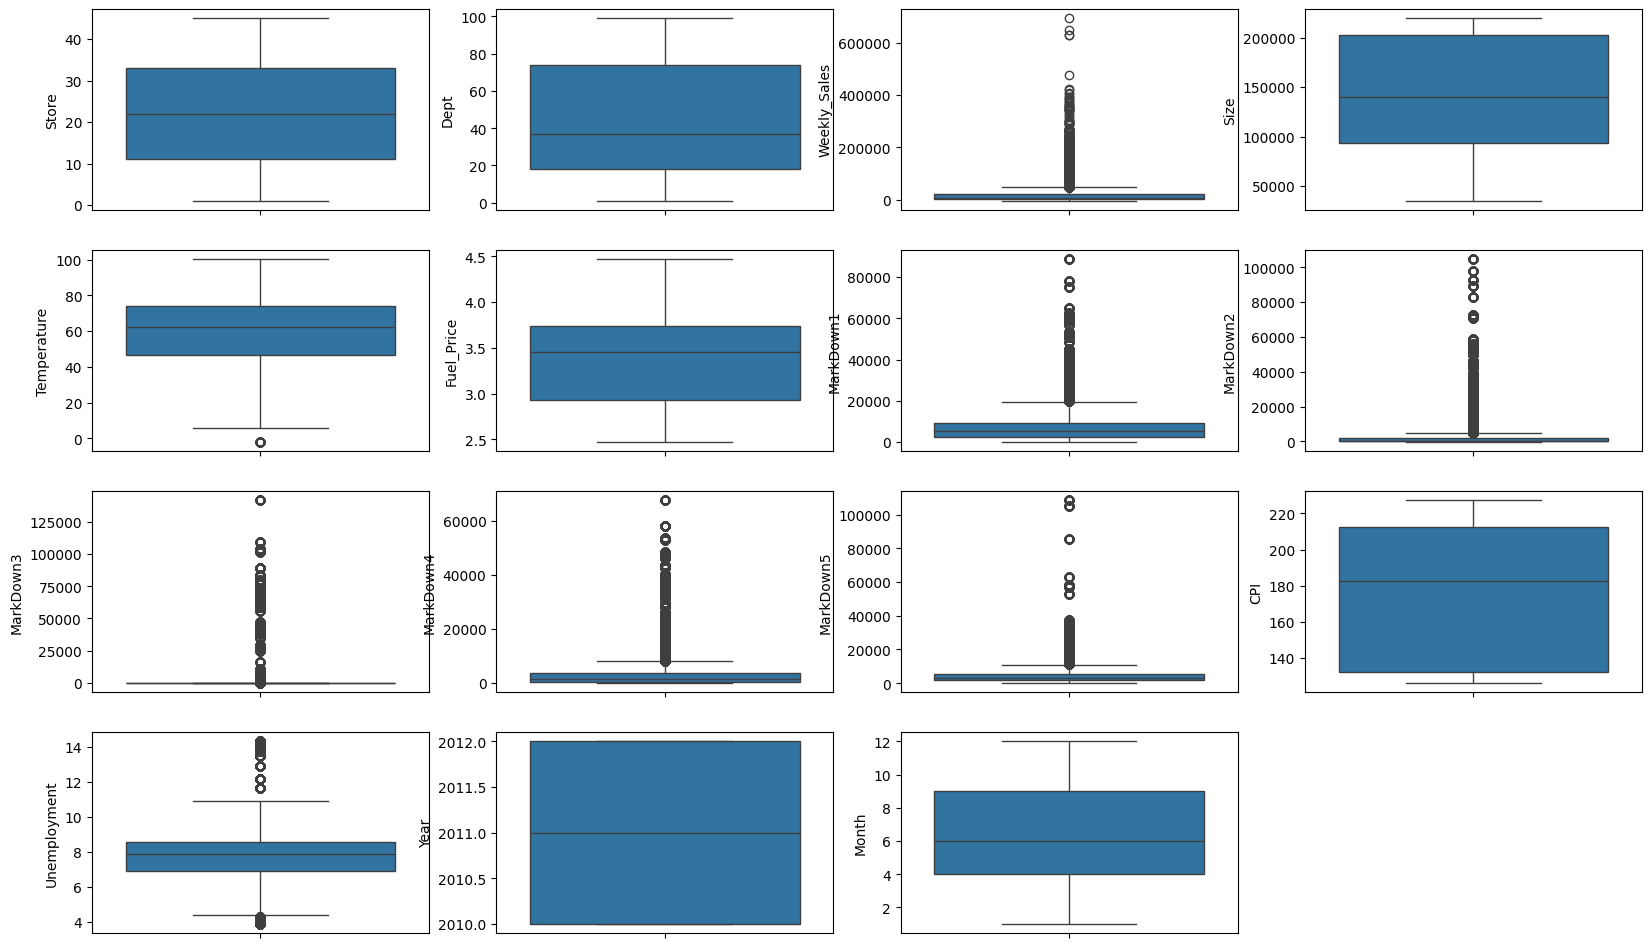

In [38]:
plt.figure(figsize=(20, 12))
for i, column in enumerate(df.select_dtypes(include='number'),1):
    plt.subplot(4,4,i)
    sns.boxplot(df[column])

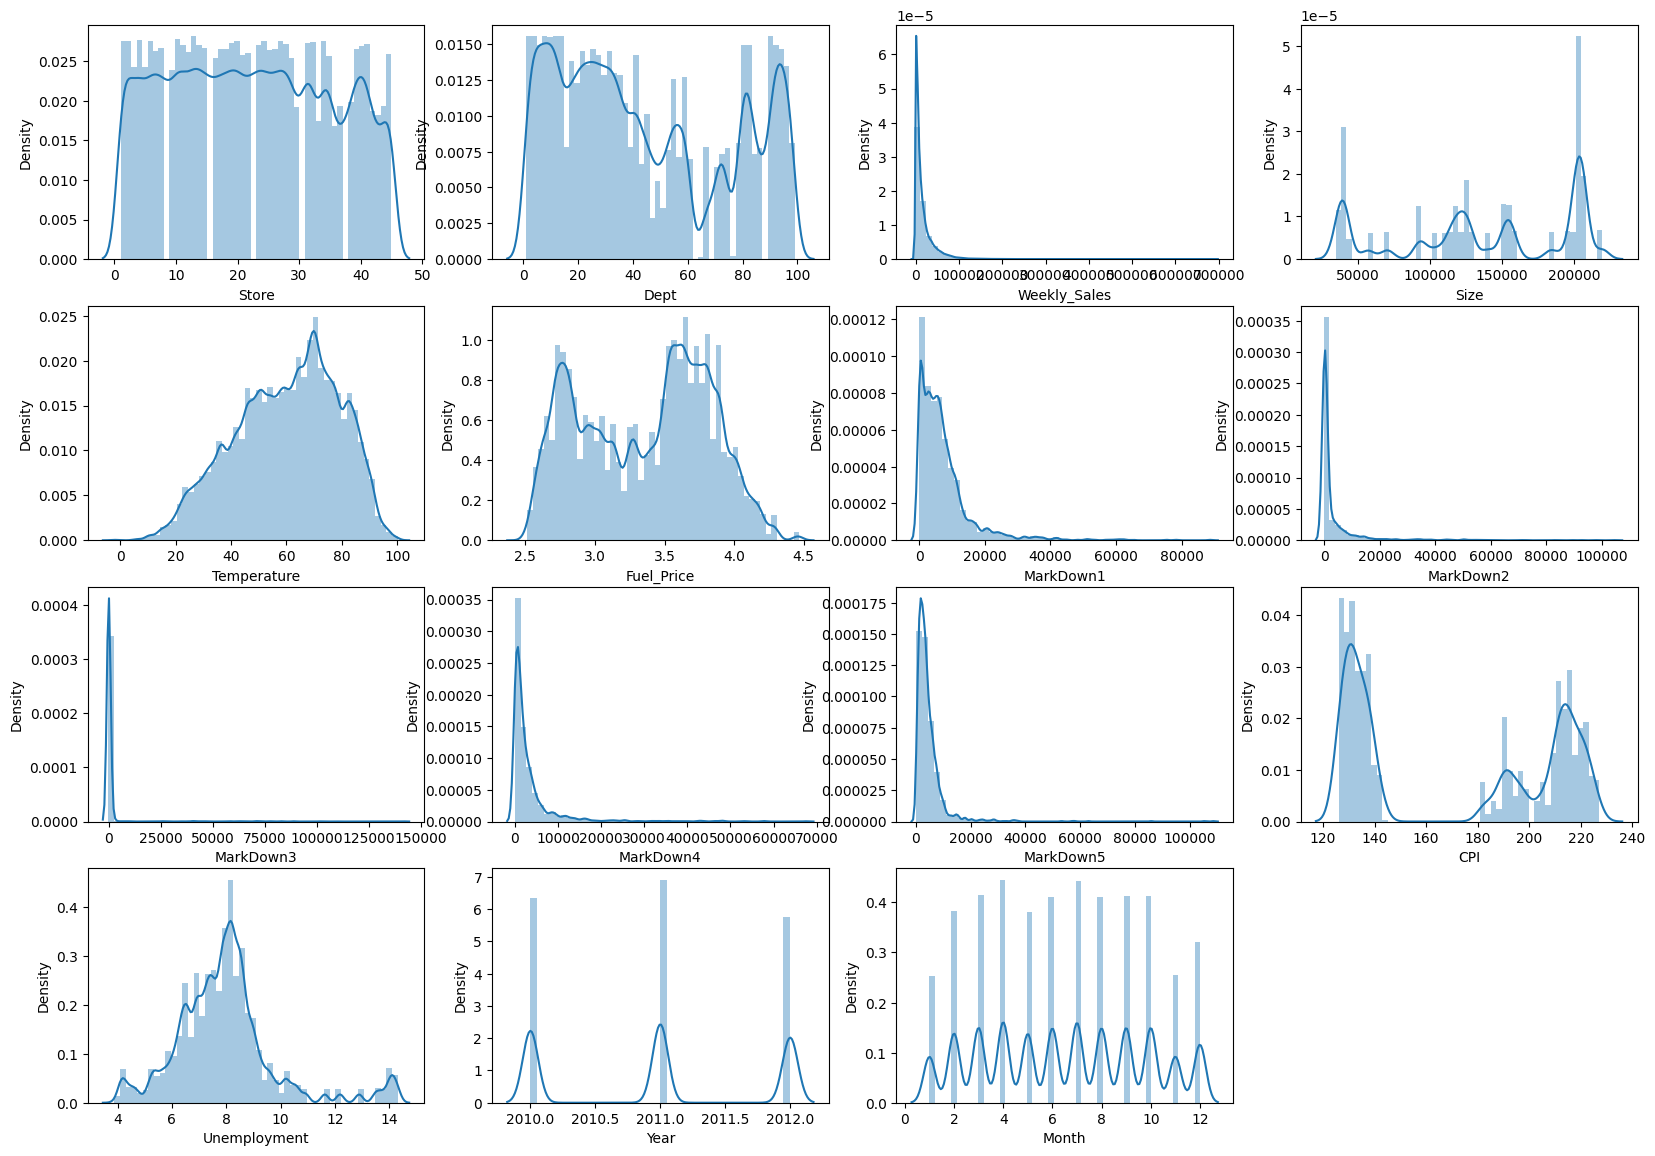

In [39]:
plt.figure(figsize=(20, 14))
for i, column in enumerate(df.select_dtypes(include='number'),1):
    plt.subplot(4,4,i)
    sns.distplot(df[column])

In [40]:
for i in df.select_dtypes(include='number'):
    skewness=df[i].skew()
    print("The skewness of",i,"= ",skewness)

The skewness of Store =  0.07776250174537733
The skewness of Dept =  0.3582231934713366
The skewness of Weekly_Sales =  3.2620081854656657
The skewness of Size =  -0.3258497664635348
The skewness of Temperature =  -0.3214041519699762
The skewness of Fuel_Price =  -0.10490149562840598
The skewness of MarkDown1 =  3.34184468638083
The skewness of MarkDown2 =  5.441261195703792
The skewness of MarkDown3 =  8.399453017706929
The skewness of MarkDown4 =  4.847500037212776
The skewness of MarkDown5 =  8.169909544116662
The skewness of CPI =  0.08521928473260011
The skewness of Unemployment =  1.1837425684974319
The skewness of Year =  0.05623644391430117
The skewness of Month =  0.04078624154148521


## Checking of Outliers

In [41]:
df.shape

(421570, 18)

In [42]:
df.dtypes

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
Type                    object
Size                     int64
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Year                     int32
Month                    int32
dtype: object

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.describe(include='object')

,Type
count,421570
unique,3
top,A
freq,215478


In [45]:
df.describe()

,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,136727.915739,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,2010.968591,6.449510
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,34875.000000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,2010.000000,1.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,93638.000000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,2010.000000,4.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,140167.000000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,2011.000000,6.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,202505.000000,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,2012.000000,9.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,2012.000000,12.000000
std,12.785297,30.492054,NaN,22711.183519,60980.583328,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,0.796876,3.243217


In [46]:
df=df.drop('Date',axis=1)

In [47]:
df.isnull().sum()

Store                0
Dept                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Year                 0
Month                0
dtype: int64

## Performing Bivariate Analysis

In [48]:
df['MarkDown1'].skew()

np.float64(3.34184468638083)

In [49]:
df['MarkDown2'].skew()

np.float64(5.441261195703792)

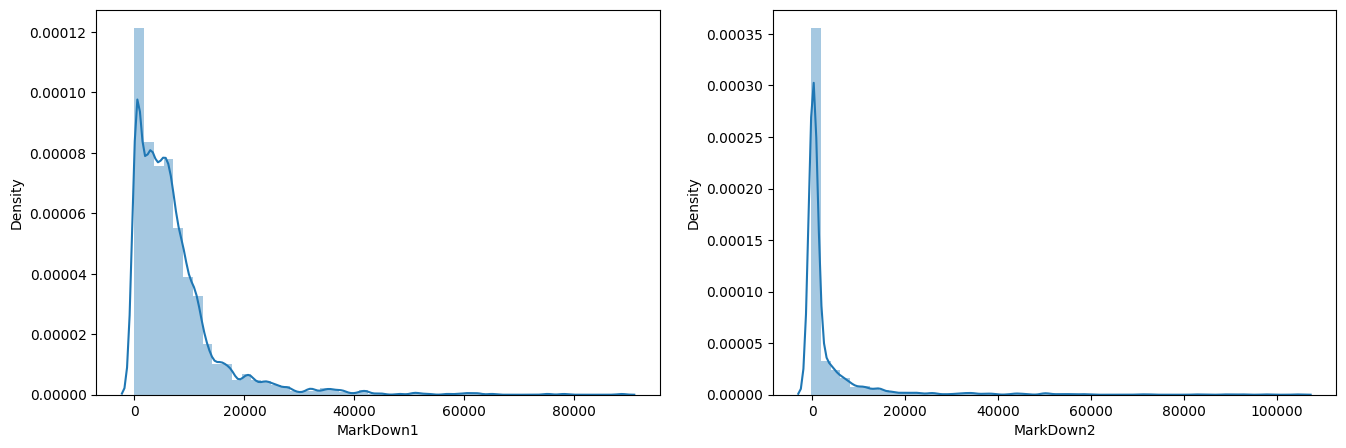

In [50]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['MarkDown1'])

plt.subplot(1,2,2)
sns.distplot(df['MarkDown2'])
plt.show()

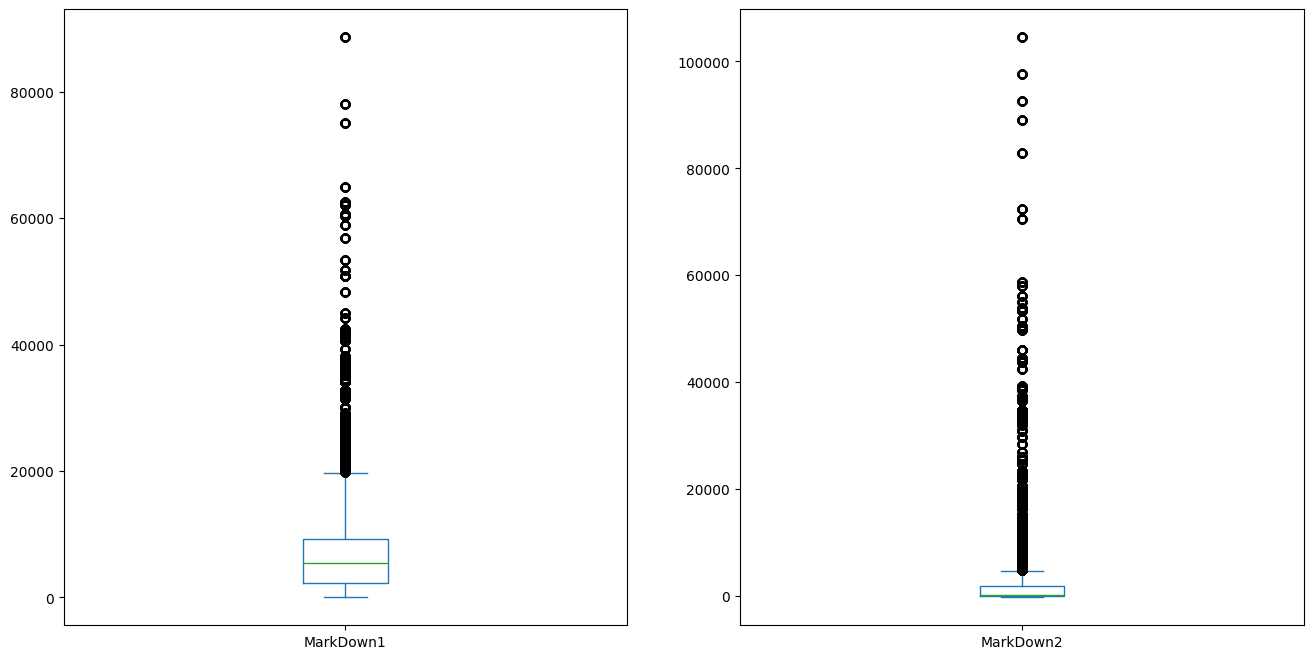

In [51]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
df['MarkDown1'].plot(kind='box')

plt.subplot(1,2,2)
df['MarkDown2'].plot(kind='box')
plt.show()

In [52]:
Tp=df['Type']
Tp

0         A
1         A
2         A
3         A
4         A
         ..
421565    B
421566    B
421567    B
421568    B
421569    B
Name: Type, Length: 421570, dtype: object

In [53]:
df=df.drop('Type', axis=1)

In [54]:
Hd=df['IsHoliday']
Hd

0         False
1          True
2         False
3         False
4         False
          ...  
421565    False
421566    False
421567    False
421568    False
421569    False
Name: IsHoliday, Length: 421570, dtype: bool

In [55]:
df=df.drop('IsHoliday',axis=1)
df

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
0,1,1,24924.50,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2
1,1,1,46039.49,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2
2,1,1,41595.55,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2
3,1,1,19403.54,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2
4,1,1,21827.90,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,508.37,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9
421566,45,98,628.10,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,2012,10
421567,45,98,1061.02,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,2012,10
421568,45,98,760.01,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,2012,10


In [56]:
df.corr()

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
Store,1.000000,0.024004,-0.085195,-0.182881,-0.050097,0.065290,-0.119588,-0.035173,-0.031556,-0.009941,-0.026634,-0.211088,0.208552,0.002997,0.001011
Dept,0.024004,1.000000,0.148032,-0.002966,0.004437,0.003572,-0.002426,0.000290,0.001784,0.004257,0.000109,-0.007477,0.007837,0.003738,0.000904
Weekly_Sales,-0.085195,0.148032,1.000000,0.243828,-0.002312,-0.000120,0.085251,0.024130,0.060385,0.045414,0.090362,-0.020921,-0.025864,-0.010111,0.028409
Size,-0.182881,-0.002966,0.243828,1.000000,-0.058313,0.003361,0.345673,0.108827,0.048913,0.168196,0.304575,-0.003314,-0.068238,-0.004975,-0.001210
Temperature,-0.050097,0.004437,-0.002312,-0.058313,1.000000,0.143859,-0.040594,-0.323927,-0.096880,-0.063947,-0.017544,0.182112,0.096730,0.065814,0.235983
Fuel_Price,0.065290,0.003572,-0.000120,0.003361,0.143859,1.000000,0.061371,-0.220895,-0.102092,-0.044986,-0.128065,-0.164210,-0.033853,0.779633,-0.040876
MarkDown1,-0.119588,-0.002426,0.085251,0.345673,-0.040594,0.061371,1.000000,0.024486,-0.108115,0.819238,0.160257,-0.055558,0.050285,0.141332,-0.176188
MarkDown2,-0.035173,0.000290,0.024130,0.108827,-0.323927,-0.220895,0.024486,1.000000,-0.050108,-0.007768,-0.007440,-0.039534,0.020940,-0.222109,-0.005310
MarkDown3,-0.031556,0.001784,0.060385,0.048913,-0.096880,-0.102092,-0.108115,-0.050108,1.000000,-0.071095,-0.026467,-0.023590,0.012818,-0.319162,0.187871
MarkDown4,-0.009941,0.004257,0.045414,0.168196,-0.063947,-0.044986,0.819238,-0.007768,-0.071095,1.000000,0.107792,-0.049628,0.024963,0.126469,-0.194865


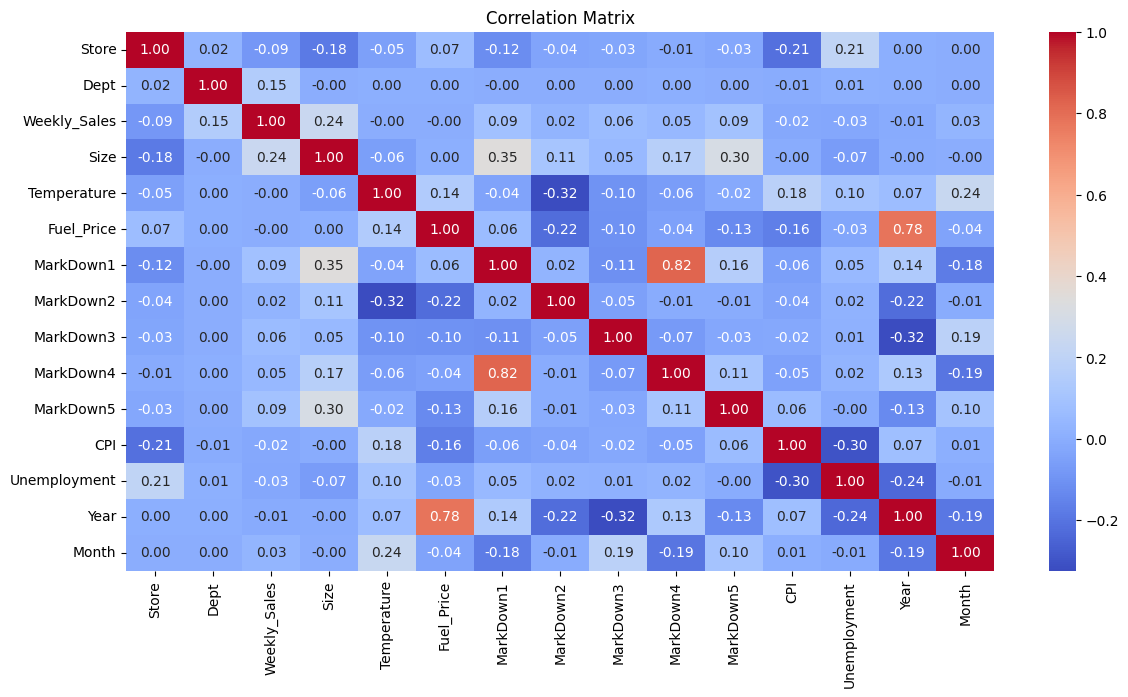

In [57]:
plt.figure(figsize=(14, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## Treating Outliers :🐛 

In [58]:
q1=df.quantile(0.25)
q1

Store              11.000000
Dept               18.000000
Weekly_Sales     2079.650000
Size            93638.000000
Temperature        46.680000
Fuel_Price          2.933000
MarkDown1        2240.270000
MarkDown2          41.600000
MarkDown3           5.080000
MarkDown4         504.220000
MarkDown5        1878.440000
CPI               132.022667
Unemployment        6.891000
Year             2010.000000
Month               4.000000
Name: 0.25, dtype: float64

In [59]:
q3=df.quantile(0.75)
q3

Store               33.000000
Dept                74.000000
Weekly_Sales     20205.852500
Size            202505.000000
Temperature         74.280000
Fuel_Price           3.738000
MarkDown1         9210.900000
MarkDown2         1926.940000
MarkDown3          103.990000
MarkDown4         3595.040000
MarkDown5         5563.800000
CPI                212.416993
Unemployment         8.572000
Year              2012.000000
Month                9.000000
Name: 0.75, dtype: float64

In [60]:
Iqr=q3-q1
Iqr

Store               22.000000
Dept                56.000000
Weekly_Sales     18126.202500
Size            108867.000000
Temperature         27.600000
Fuel_Price           0.805000
MarkDown1         6970.630000
MarkDown2         1885.340000
MarkDown3           98.910000
MarkDown4         3090.820000
MarkDown5         3685.360000
CPI                 80.394326
Unemployment         1.681000
Year                 2.000000
Month                5.000000
dtype: float64

In [61]:
M1_high=q3.MarkDown1+1.5*Iqr.MarkDown1
M1_high

np.float64(19666.845)

In [62]:
M1_low=q1.MarkDown1-1.5*Iqr.MarkDown1
M1_low

np.float64(-8215.675)

In [63]:
M2_high=q3.MarkDown2+1.5*Iqr.MarkDown2
M2_high

np.float64(4754.950000000001)

In [64]:
M2_low=q1.MarkDown2-1.5*Iqr.MarkDown2
M2_low

np.float64(-2786.4100000000003)

In [65]:
high_ws=q3.Weekly_Sales+1.5*Iqr.Weekly_Sales
high_ws

np.float64(47395.15625)

In [66]:
low_ws=q1.Weekly_Sales-1.5*Iqr.Weekly_Sales
low_ws

np.float64(-25109.653749999998)

## Method of treatment is : Capping

In [67]:
new_df = df.copy()
new_df['MarkDown1']=np.where(new_df['MarkDown1']>M1_high,
                    M1_high,
                    np.where(new_df['MarkDown1']<M1_low,
                    M1_low,
                    new_df['MarkDown1']
    )
)

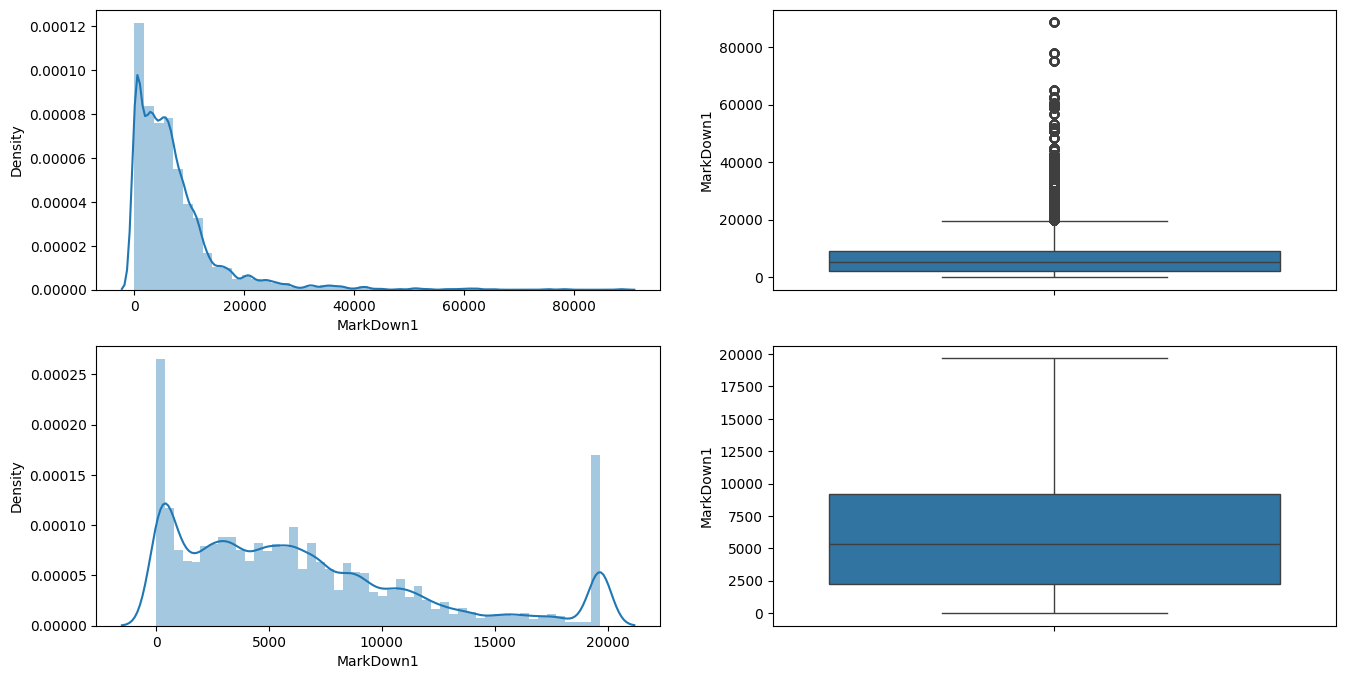

In [68]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['MarkDown1'])

plt.subplot(2,2,2)
sns.boxplot(df['MarkDown1'])

plt.subplot(2,2,3)
sns.distplot(new_df['MarkDown1'])

plt.subplot(2,2,4)
sns.boxplot(new_df['MarkDown1'])

plt.show()

In [69]:
new_df['MarkDown2']=np.where(new_df['MarkDown2']>M2_high,
                    M2_high,
                    np.where(new_df['MarkDown2']<M2_low,
                    M2_low,
                    new_df['MarkDown2']
    )
)

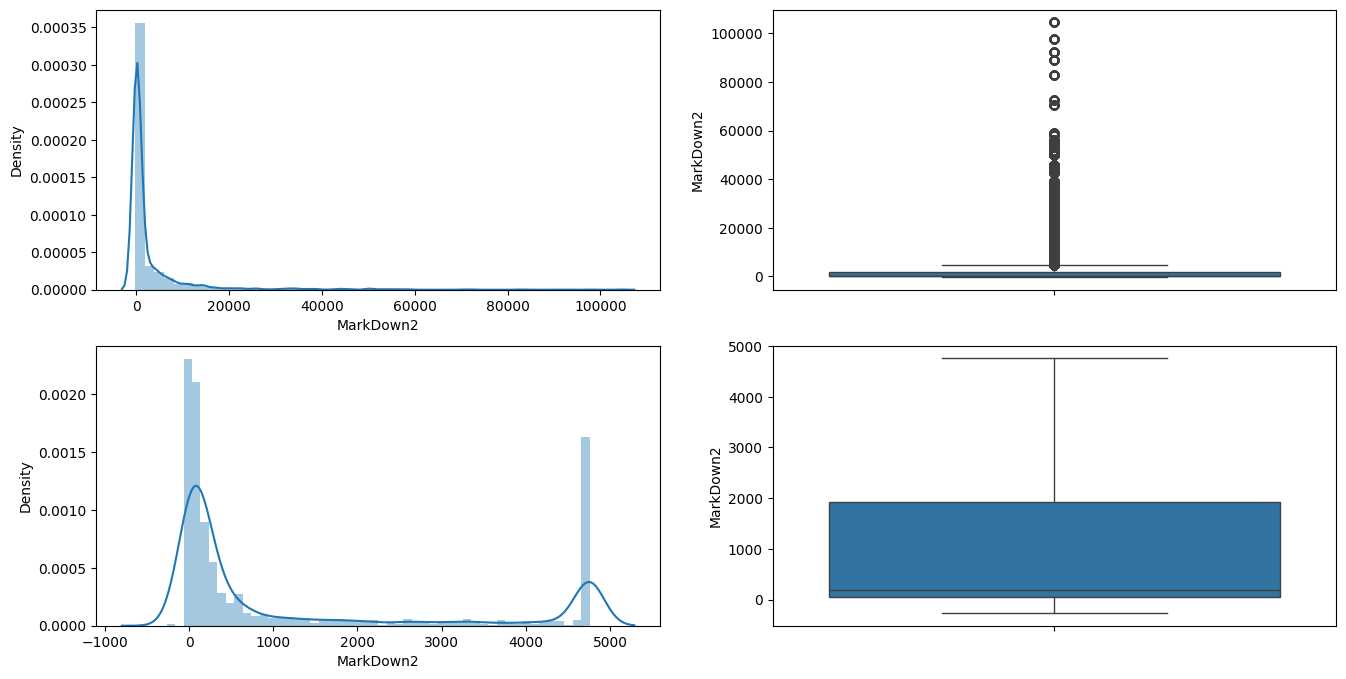

In [70]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['MarkDown2'])

plt.subplot(2,2,2)
sns.boxplot(df['MarkDown2'])

plt.subplot(2,2,3)
sns.distplot(new_df['MarkDown2'])

plt.subplot(2,2,4)
sns.boxplot(new_df['MarkDown2'])

plt.show()

In [71]:
new_df['Weekly_Sales']=np.where(new_df['Weekly_Sales']>high_ws,
                    high_ws,
                    np.where(new_df['Weekly_Sales']<low_ws,
                    low_ws,
                    new_df['Weekly_Sales']
    )
)

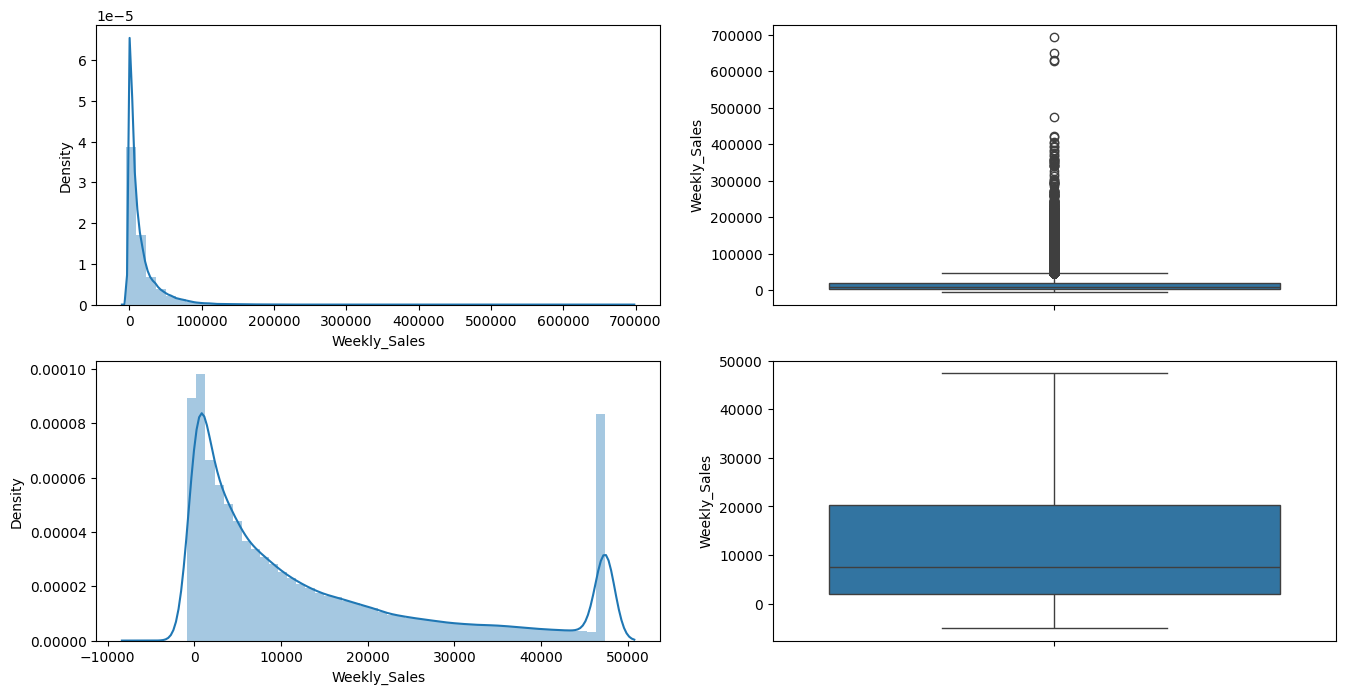

In [72]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['Weekly_Sales'])

plt.subplot(2,2,2)
sns.boxplot(df['Weekly_Sales'])

plt.subplot(2,2,3)
sns.distplot(new_df['Weekly_Sales'])

plt.subplot(2,2,4)
sns.boxplot(new_df['Weekly_Sales'])

plt.show()

***
# Removing Outliers of - Markdown3 nd Markdown4
***

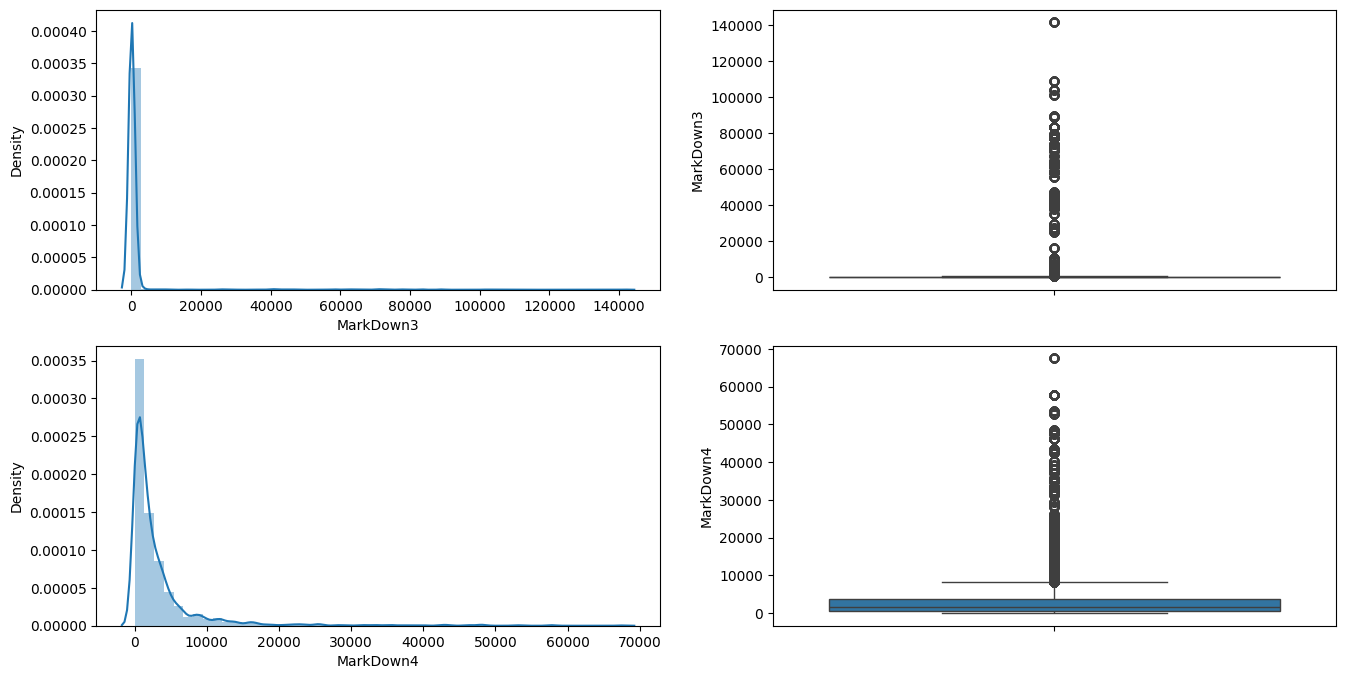

In [73]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['MarkDown3'])

plt.subplot(2,2,2)
sns.boxplot(df['MarkDown3'])

plt.subplot(2,2,3)
sns.distplot(df['MarkDown4'])

plt.subplot(2,2,4)
sns.boxplot(df['MarkDown4'])

plt.show()

In [74]:
M3_high=q3.MarkDown3+1.5*Iqr.MarkDown3
M3_high

np.float64(252.35500000000002)

In [75]:
M3_low=q1.MarkDown3-1.5*Iqr.MarkDown3
M3_low

np.float64(-143.285)

In [76]:
M4_high=q3.MarkDown4+1.5*Iqr.MarkDown4
M4_high

np.float64(8231.27)

In [77]:
M4_low=q1.MarkDown4-1.5*Iqr.MarkDown4
M4_low

np.float64(-4132.009999999999)

In [78]:
new_df['MarkDown3']=np.where(new_df['MarkDown3']>M3_high,
                    M3_high,
                    np.where(new_df['MarkDown3']<M3_low,
                    M3_low,
                    new_df['MarkDown3']
    )
)

In [79]:
new_df['MarkDown4']=np.where(new_df['MarkDown4']>M4_high,
                    M4_high,
                    np.where(new_df['MarkDown4']<M4_low,
                    M4_low,
                    new_df['MarkDown4']
    )
)

In [80]:
M5_high=q3.MarkDown5+1.5*Iqr.MarkDown5
M5_high

np.float64(11091.84)

In [81]:
M5_low=q1.MarkDown5-1.5*Iqr.MarkDown5
M5_low

np.float64(-3649.6)

In [82]:
new_df['MarkDown5']=np.where(new_df['MarkDown5']>M5_high,
                    M5_high,
                    np.where(new_df['MarkDown5']<M5_low,
                    M5_low,
                    new_df['MarkDown5']
    )
)

In [83]:
high_out=q3.Unemployment+1.5*Iqr.Unemployment
high_out

np.float64(11.093499999999999)

In [84]:
low_out=q1.Unemployment-1.5*Iqr.Unemployment
low_out

np.float64(4.369500000000001)

In [85]:
new_df['Unemployment']=np.where(new_df['Unemployment']>high_out,
                    high_out,
                    np.where(new_df['Unemployment']<low_out,
                    low_out,
                    new_df['Unemployment']
    )
)

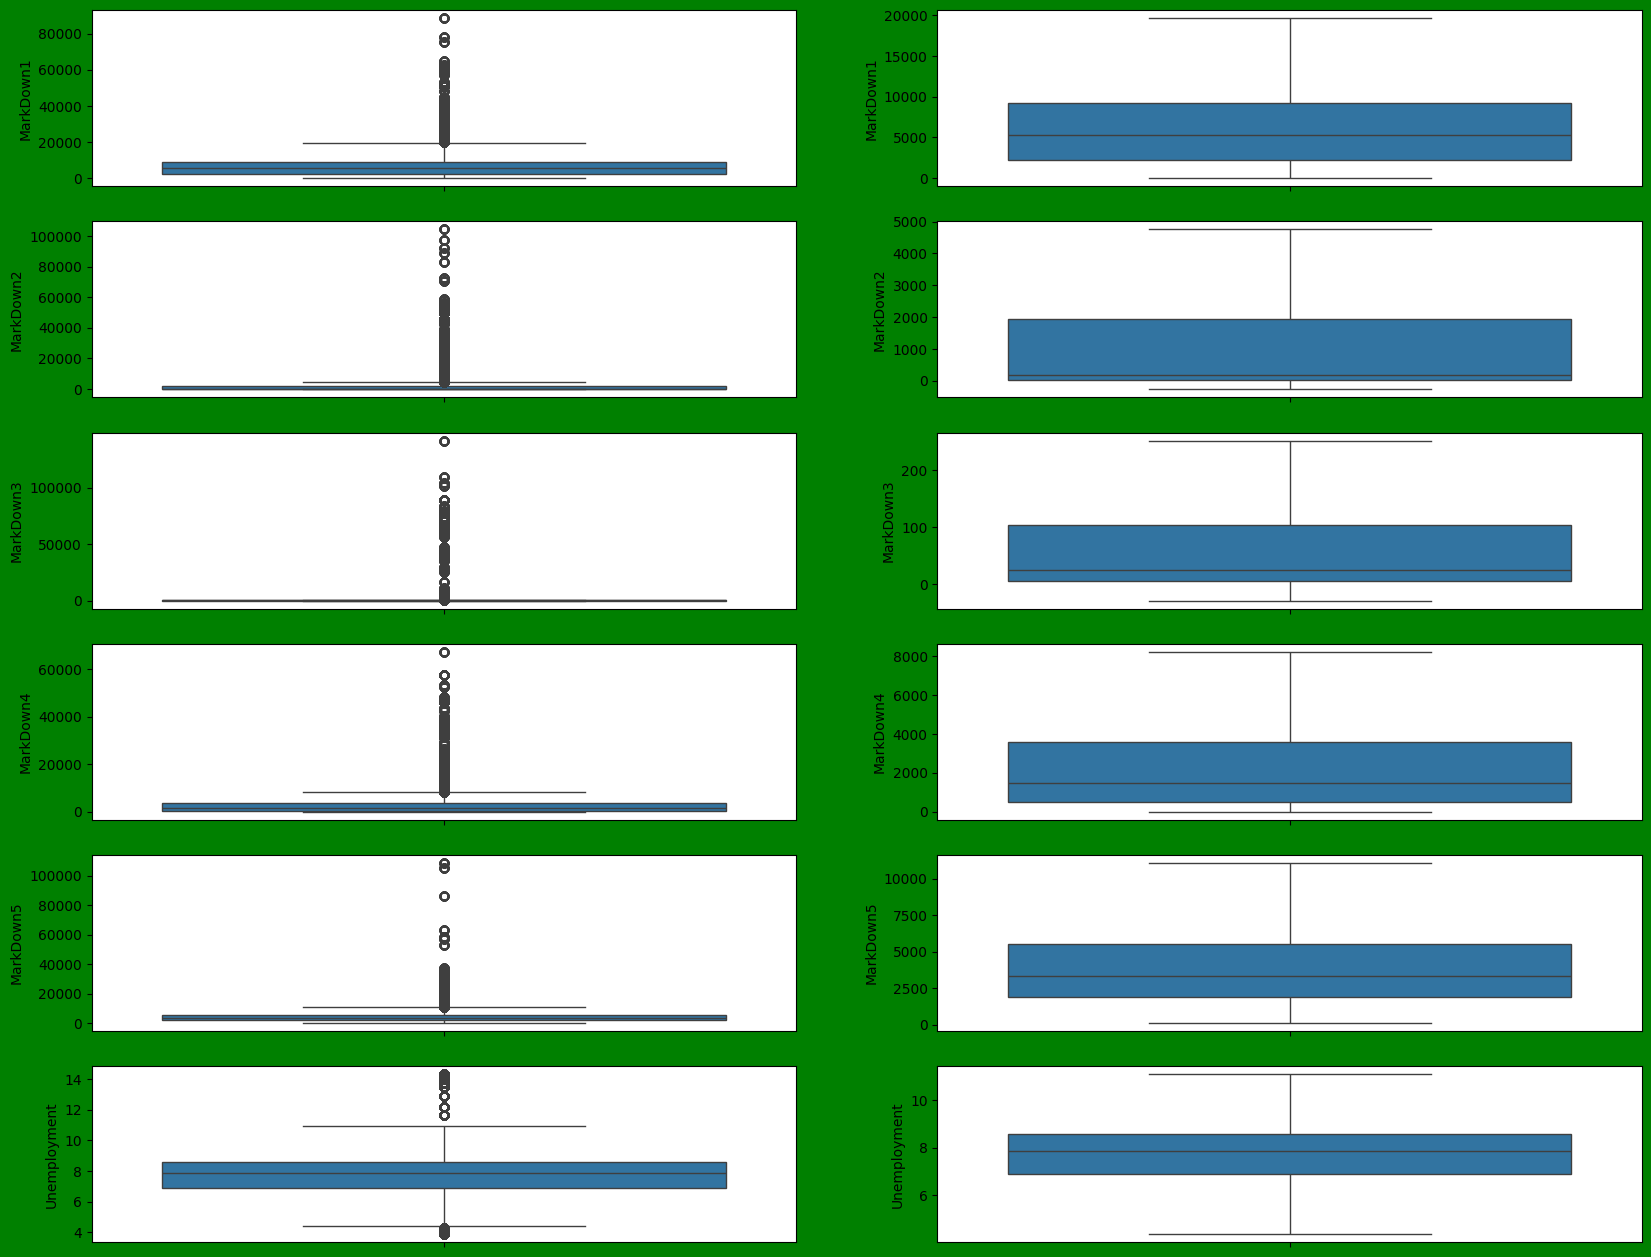

In [86]:
plt.figure(figsize=(20,16),facecolor="green")
plt.subplot(6,2,1)
sns.boxplot(df['MarkDown1'])

plt.subplot(6,2,2)
sns.boxplot(new_df['MarkDown1'])

plt.subplot(6,2,3)
sns.boxplot(df['MarkDown2'])

plt.subplot(6,2,4)
sns.boxplot(new_df['MarkDown2'])

plt.subplot(6,2,5)
sns.boxplot(df['MarkDown3'])

plt.subplot(6,2,6)
sns.boxplot(new_df['MarkDown3'])

plt.subplot(6,2,7)
sns.boxplot(df['MarkDown4'])

plt.subplot(6,2,8)
sns.boxplot(new_df['MarkDown4'])

plt.subplot(6,2,9)
sns.boxplot(df['MarkDown5'])

plt.subplot(6,2,10)
sns.boxplot(new_df['MarkDown5'])

plt.subplot(6,2,11)
sns.boxplot(df['Unemployment'])

plt.subplot(6,2,12)
sns.boxplot(new_df['Unemployment'])


plt.show()

***Here we compare Box plots....before and after removing outliers***

## Boxplot ( After Removing Outliers...)

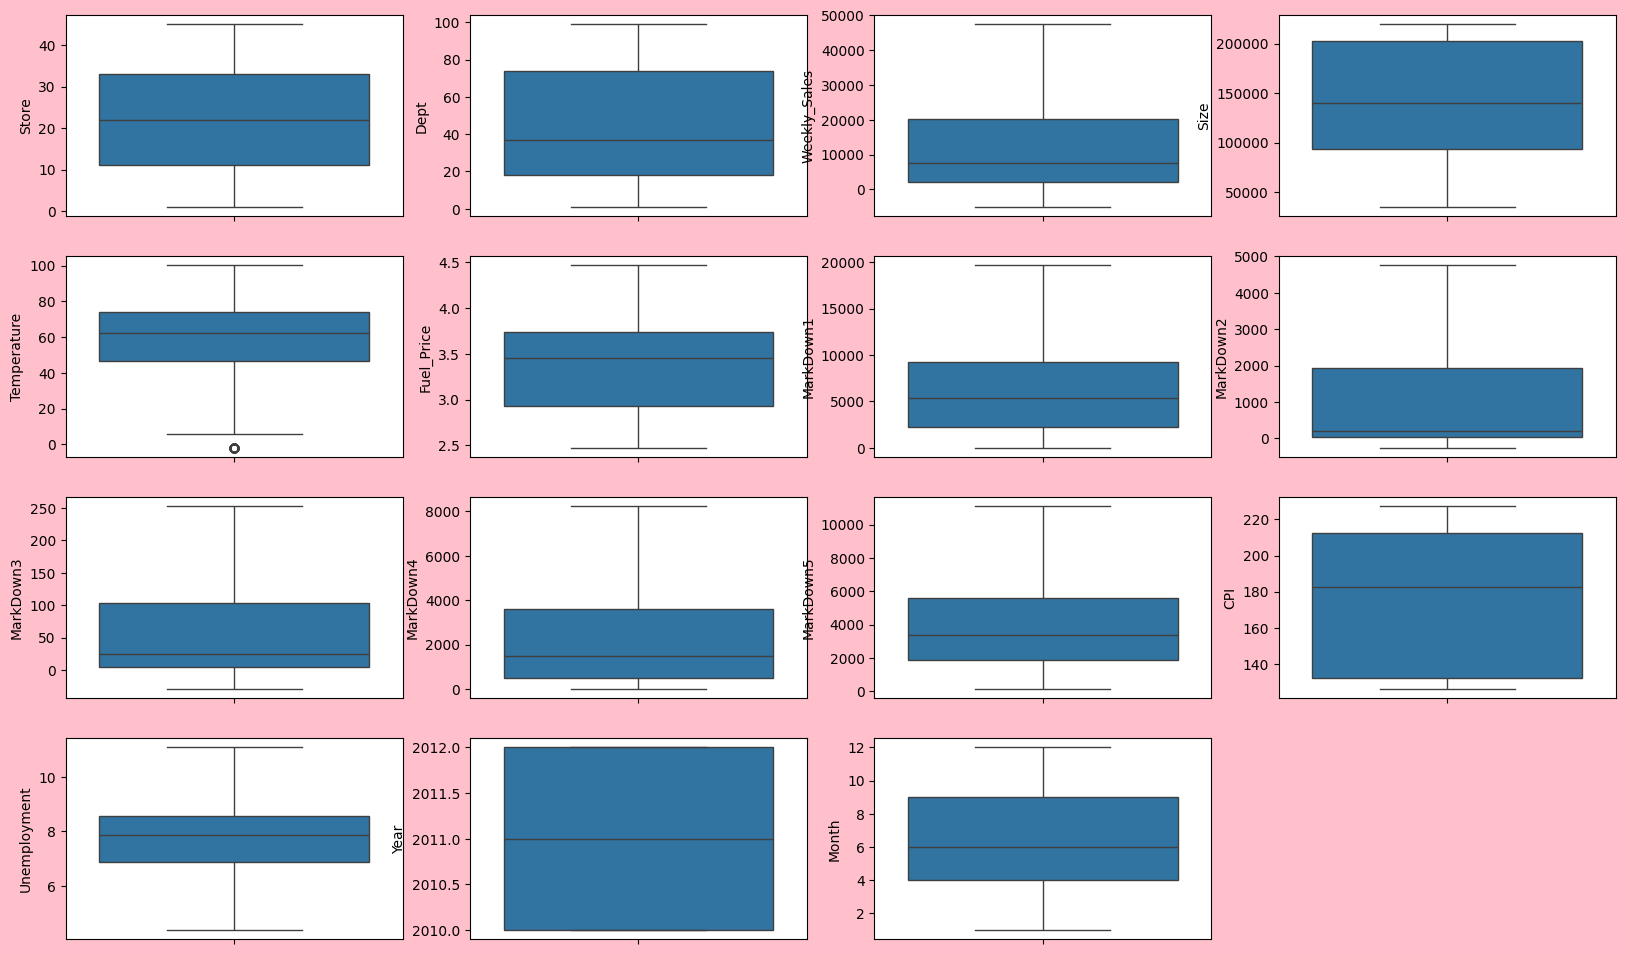

In [87]:
plt.figure(figsize=(20, 12),facecolor="pink")
for i, column in enumerate(new_df.select_dtypes(include='number'),1):
    plt.subplot(4,4,i)
    sns.boxplot(new_df[column])

## Distribution plots (distplots)

**This plot will display the distribution of a numeric column...showing how values are spread across different ranges.**

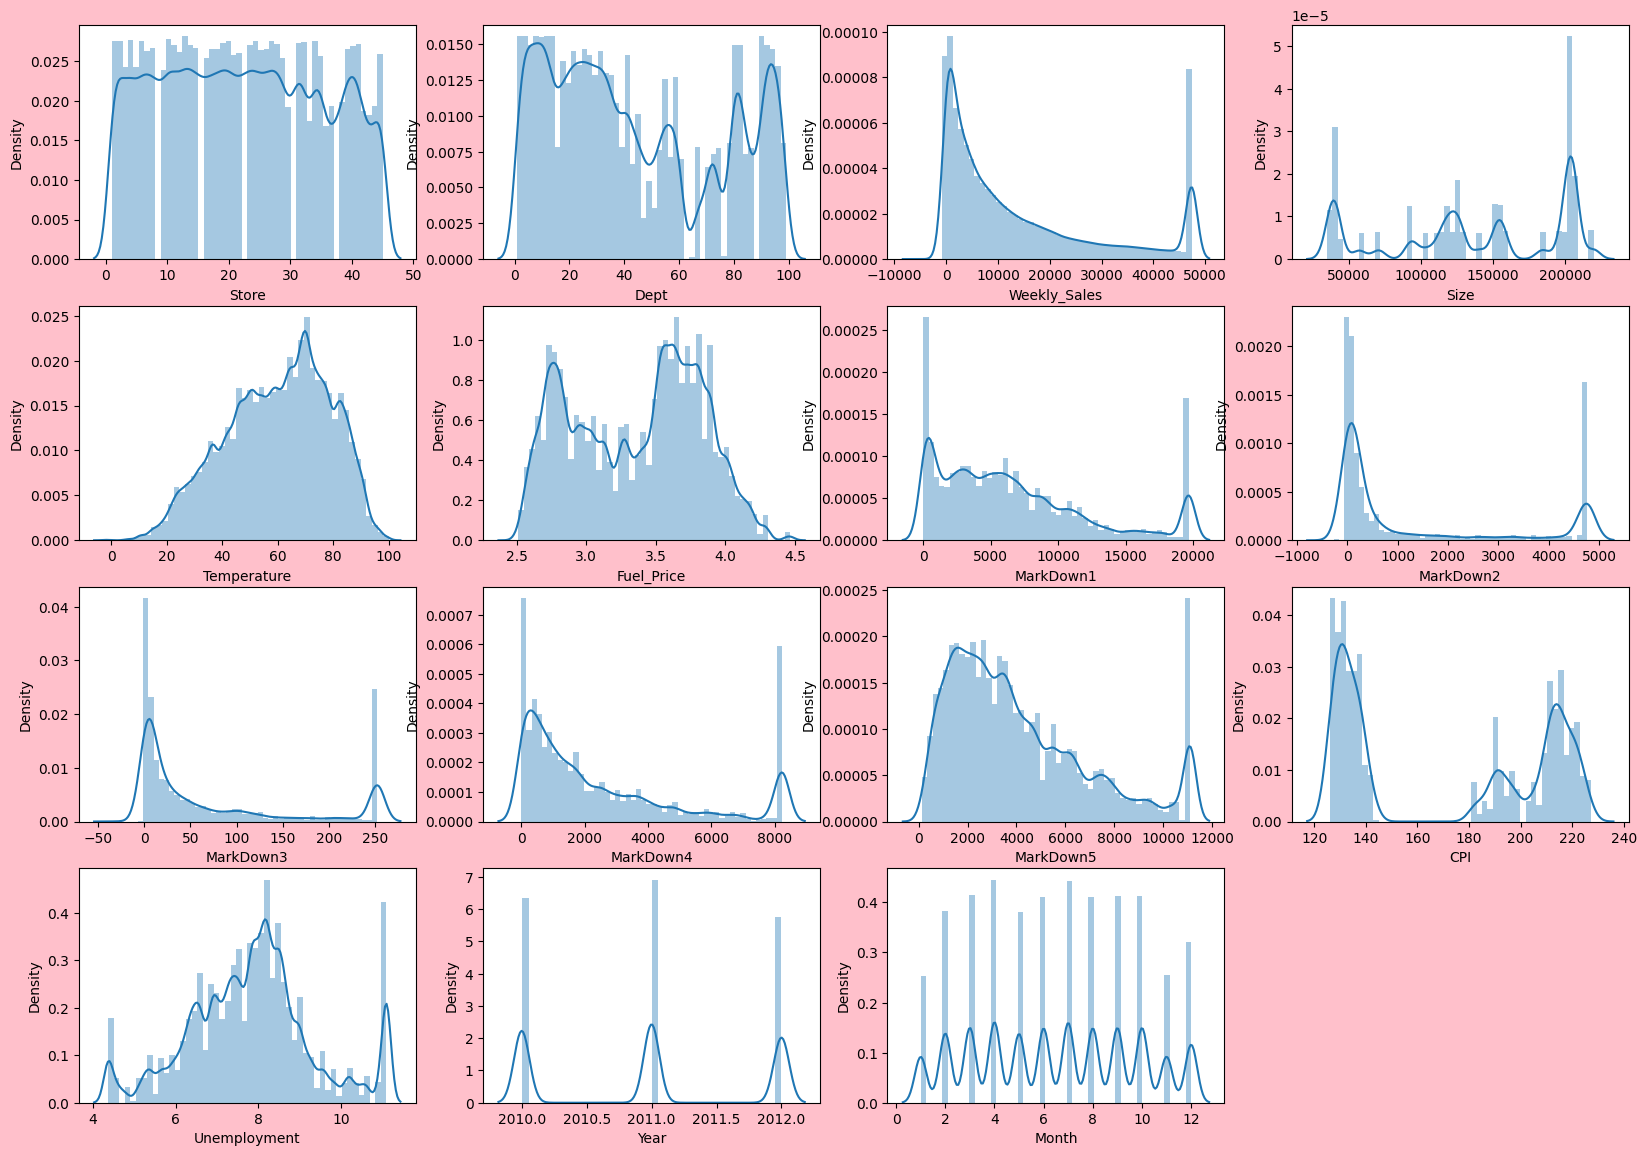

In [88]:
plt.figure(figsize=(20, 14),facecolor="pink")
for i, column in enumerate(new_df.select_dtypes(include='number'),1):
    plt.subplot(4,4,i)
    sns.distplot(new_df[column])

In [89]:
for i in new_df.select_dtypes(include='number'):
    skewness=new_df[i].skew()
    print("The skewness of",i,"= ",skewness)

The skewness of Store =  0.07776250174537733
The skewness of Dept =  0.3582231934713366
The skewness of Weekly_Sales =  1.1682384133485475
The skewness of Size =  -0.3258497664635348
The skewness of Temperature =  -0.3214041519699762
The skewness of Fuel_Price =  -0.10490149562840598
The skewness of MarkDown1 =  0.9735322105579078
The skewness of MarkDown2 =  1.2014917881854539
The skewness of MarkDown3 =  1.2007760771714502
The skewness of MarkDown4 =  1.1969709810692746
The skewness of MarkDown5 =  0.9778952750155905
The skewness of CPI =  0.08521928473260011
The skewness of Unemployment =  0.13980023921567286
The skewness of Year =  0.05623644391430117
The skewness of Month =  0.04078624154148521


In [90]:
new_df.head()

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
0,1,1,24924.50,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2
1,1,1,46039.49,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2
2,1,1,41595.55,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2
3,1,1,19403.54,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2
4,1,1,21827.90,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3


-------------------------------------------------------
## Encoding ( to make categorical into numerical)
-------------------------------------------------------

In [91]:
from sklearn.preprocessing import LabelEncoder

In [92]:
lab_enc=LabelEncoder()

In [93]:
df_1= lab_enc.fit_transform(Hd)
new_df['IsHoliday']=df_1

In [94]:
new_df.head()

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,IsHoliday
0,1,1,24924.50,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2,0
1,1,1,46039.49,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2,1
2,1,1,41595.55,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2,0
3,1,1,19403.54,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2,0
4,1,1,21827.90,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3,0


### Boxplot ( After Removing Outliers...this plot includes object).

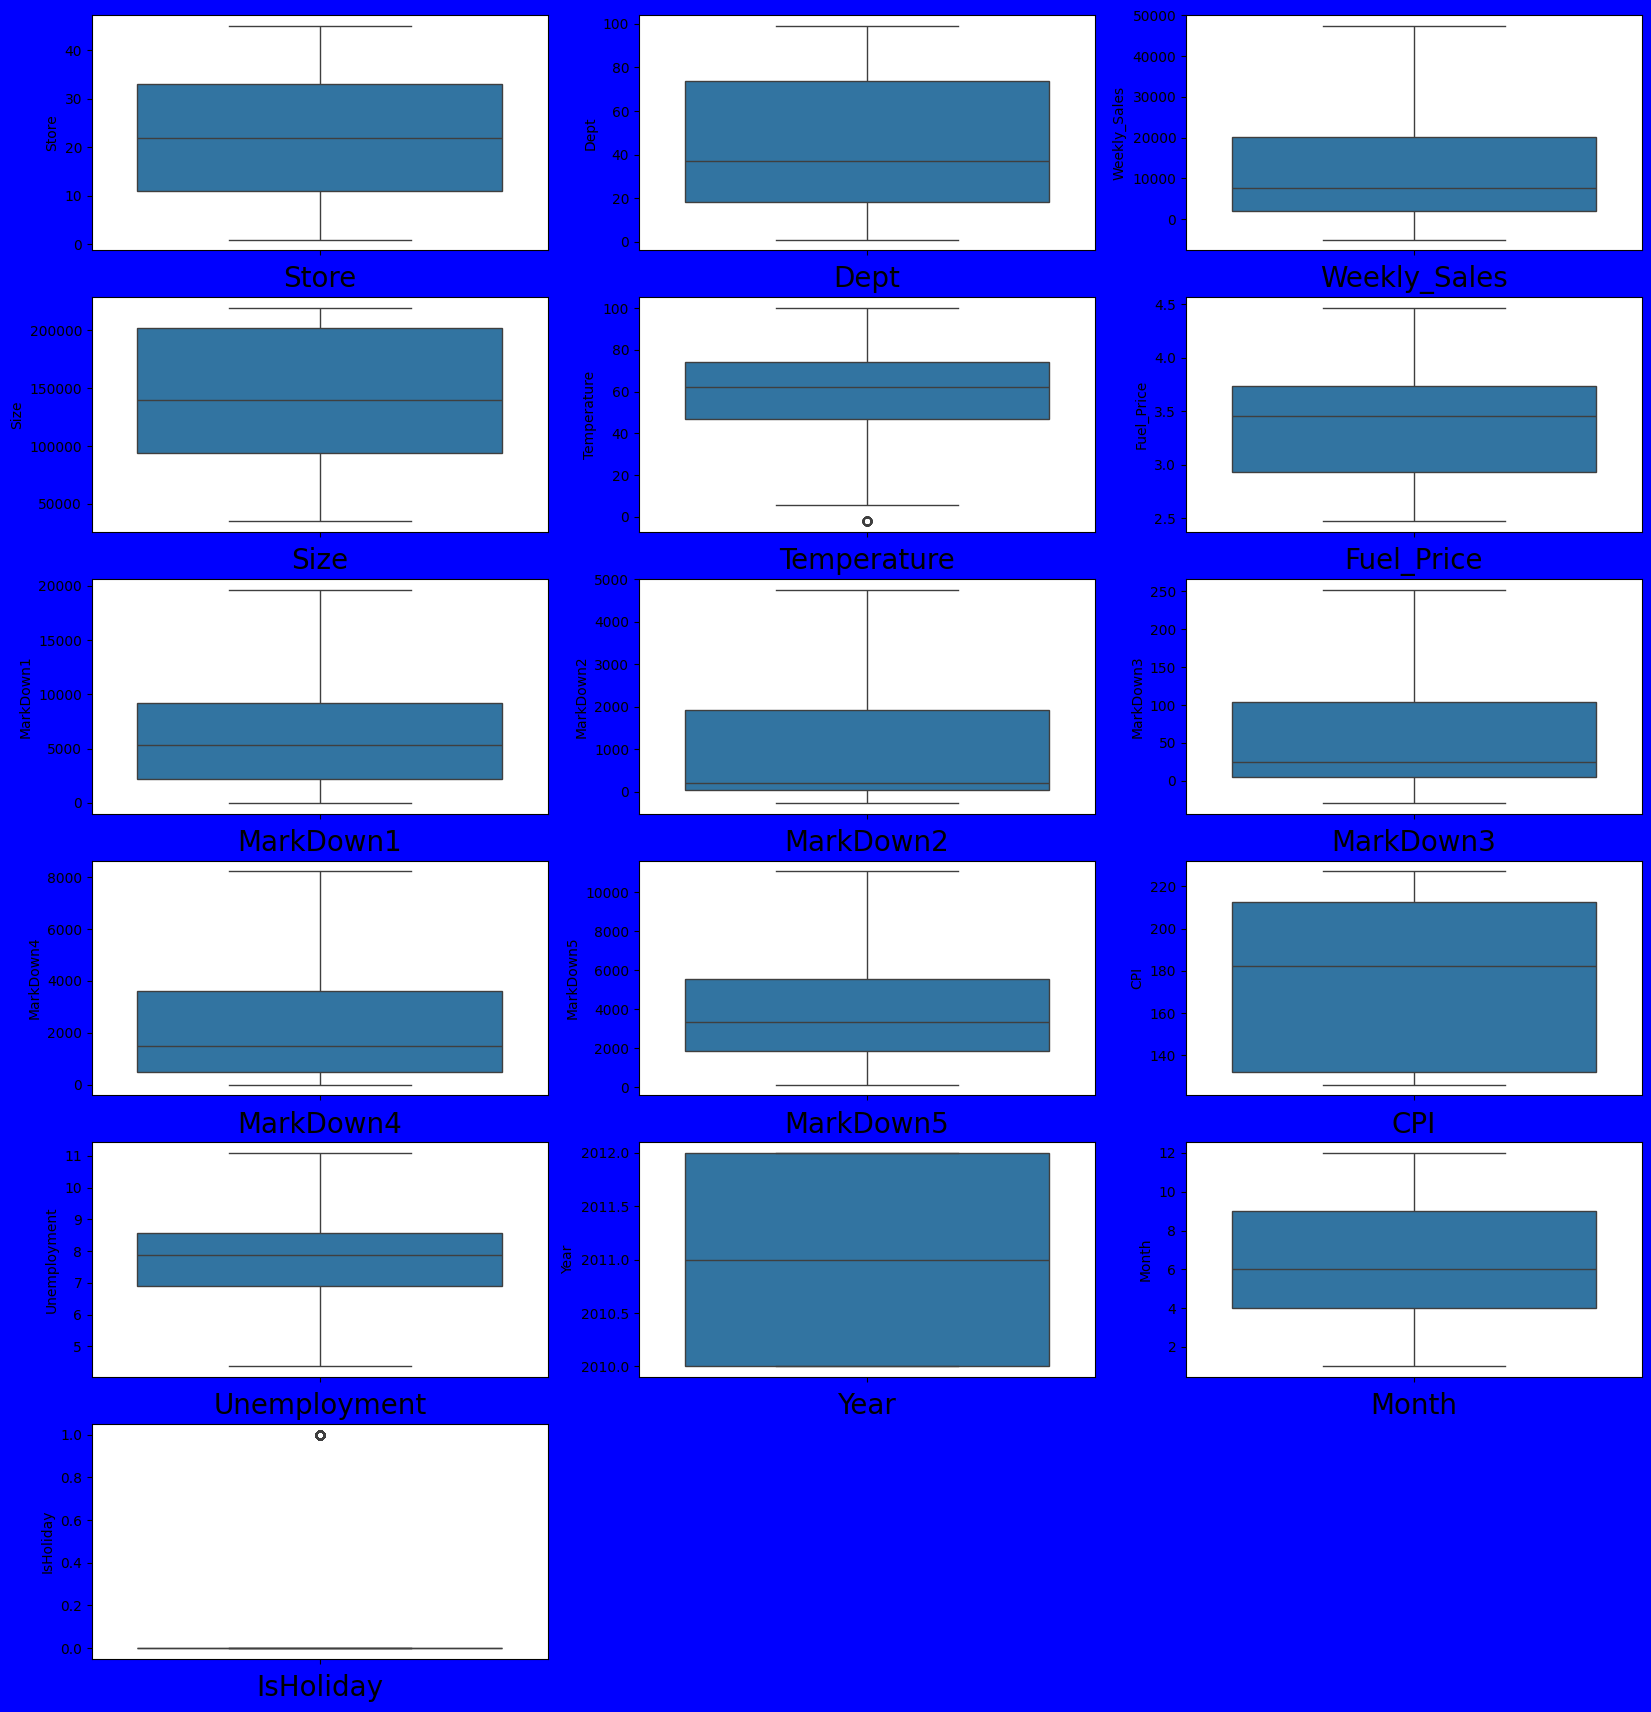

In [95]:
plt.figure(figsize=(20,25), facecolor='blue')
plotnumber =1
for column in new_df:
    if plotnumber <=19:
        ax = plt.subplot(7,3,plotnumber)
        sns.boxplot(new_df[column])
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

-------------------------------------------------
# Scaling ( to convert data in only one unit )
-----------------------------------------------

In [96]:
from sklearn.preprocessing import StandardScaler

In [97]:
scaler = StandardScaler()

In [98]:
new_df=new_df.dropna()

In [99]:
new_df

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,IsHoliday
92,1,1,18689.54,151315,59.11,3.297,10382.900,4754.95,215.070,2406.62,6551.42,217.998085,7.866,2011,11,0
93,1,1,19050.66,151315,62.25,3.308,6074.120,254.39,51.980,427.39,5988.57,218.220509,7.866,2011,11,0
94,1,1,20911.25,151315,60.14,3.236,410.310,98.00,252.355,8.00,554.92,218.467621,7.866,2011,11,1
95,1,1,25293.49,151315,48.91,3.172,5629.510,68.00,252.355,2084.64,11091.84,218.714733,7.866,2011,12,0
96,1,1,33305.92,151315,43.93,3.158,4640.650,19.00,105.020,3639.42,11091.84,218.961846,7.866,2011,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421561,45,98,346.04,118221,75.09,3.867,19666.845,6.00,92.930,6988.31,3992.13,191.461281,8.684,2012,8,0
421562,45,98,352.44,118221,75.70,3.911,11024.450,12.80,52.630,1854.77,2055.70,191.577676,8.684,2012,9,1
421564,45,98,467.30,118221,65.32,4.038,8452.200,92.28,63.240,2376.38,8670.40,191.856704,8.684,2012,9,0
421565,45,98,508.37,118221,64.88,3.997,4556.610,20.64,1.500,1601.01,3288.25,192.013558,8.684,2012,9,0


In [100]:
y=new_df['Weekly_Sales']
y.reset_index()

,index,Weekly_Sales
0,92,18689.54
1,93,19050.66
2,94,20911.25
3,95,25293.49
4,96,33305.92
...,...,...
97051,421561,346.04
97052,421562,352.44
97053,421564,467.30
97054,421565,508.37


In [101]:
x=new_df.drop('Weekly_Sales',axis=1)

In [102]:
x.reset_index()

,index,Store,Dept,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,IsHoliday
0,92,1,1,151315,59.11,3.297,10382.900,4754.95,215.070,2406.62,6551.42,217.998085,7.866,2011,11,0
1,93,1,1,151315,62.25,3.308,6074.120,254.39,51.980,427.39,5988.57,218.220509,7.866,2011,11,0
2,94,1,1,151315,60.14,3.236,410.310,98.00,252.355,8.00,554.92,218.467621,7.866,2011,11,1
3,95,1,1,151315,48.91,3.172,5629.510,68.00,252.355,2084.64,11091.84,218.714733,7.866,2011,12,0
4,96,1,1,151315,43.93,3.158,4640.650,19.00,105.020,3639.42,11091.84,218.961846,7.866,2011,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97051,421561,45,98,118221,75.09,3.867,19666.845,6.00,92.930,6988.31,3992.13,191.461281,8.684,2012,8,0
97052,421562,45,98,118221,75.70,3.911,11024.450,12.80,52.630,1854.77,2055.70,191.577676,8.684,2012,9,1
97053,421564,45,98,118221,65.32,4.038,8452.200,92.28,63.240,2376.38,8670.40,191.856704,8.684,2012,9,0
97054,421565,45,98,118221,64.88,3.997,4556.610,20.64,1.500,1601.01,3288.25,192.013558,8.684,2012,9,0


In [103]:
scaled = scaler.fit_transform(x)

In [104]:
Df=pd.DataFrame(scaled)

In [105]:
Df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,-1.598238,-1.436911,-0.076450,0.096458,-1.149800,0.484096,1.830951,1.502463,-0.129670,0.686667,1.090257,0.310755,-2.040705,1.298269,-0.338772
1,-1.598238,-1.436911,-0.076450,0.268384,-1.110515,-0.298185,-0.574324,-0.273740,-0.863297,0.489650,1.095866,0.310755,-2.040705,1.298269,-0.338772
2,-1.598238,-1.436911,-0.076450,0.152854,-1.367656,-1.326478,-0.657904,1.908531,-1.018749,-1.412322,1.102098,0.310755,-2.040705,1.298269,2.951842
3,-1.598238,-1.436911,-0.076450,-0.462029,-1.596226,-0.378906,-0.673938,1.908531,-0.249016,2.275977,1.108330,0.310755,-2.040705,1.576633,-0.338772
4,-1.598238,-1.436911,-0.076450,-0.734702,-1.646225,-0.558438,-0.700125,0.303915,0.327284,2.275977,1.114562,0.310755,-2.040705,1.576633,-0.338772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97051,2.056889,1.783615,-0.722806,0.971420,0.885899,2.169642,-0.707073,0.172244,1.568593,-0.209176,0.421021,0.833066,0.490027,0.463177,-0.338772
97052,2.056889,1.783615,-0.722806,1.004820,1.043041,0.600572,-0.703439,-0.266661,-0.334220,-0.886995,0.423957,0.833066,0.490027,0.741541,2.951842
97053,2.056889,1.783615,-0.722806,0.436478,1.496609,0.133567,-0.660961,-0.151108,-0.140878,1.428386,0.430994,0.833066,0.490027,0.741541,-0.338772
97054,2.056889,1.783615,-0.722806,0.412386,1.350182,-0.573696,-0.699249,-0.823514,-0.428279,-0.455559,0.434949,0.833066,0.490027,0.741541,-0.338772


## VIF

In [106]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [107]:
vif=variance_inflation_factor

In [108]:
VIF=pd.DataFrame()

In [109]:
VIF['vif']=[vif(Df.values,i) for i in range (Df.shape[1])]

In [110]:
VIF['features'] = x.columns

In [111]:
VIF

,vif,features
0,1.167564,Store
1,1.000471,Dept
2,1.351113,Size
3,3.014260,Temperature
4,1.807227,Fuel_Price
5,2.617859,MarkDown1
6,1.969515,MarkDown2
7,2.204325,MarkDown3
8,2.486917,MarkDown4
9,1.357682,MarkDown5


---------------------------------------------
# Train-test Split : to train and test data
----------------------------------------------

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
Y = pd.DataFrame(y)

In [114]:
Y.reset_index()

,index,Weekly_Sales
0,92,18689.54
1,93,19050.66
2,94,20911.25
3,95,25293.49
4,96,33305.92
...,...,...
97051,421561,346.04
97052,421562,352.44
97053,421564,467.30
97054,421565,508.37


In [115]:
Df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,-1.598238,-1.436911,-0.076450,0.096458,-1.149800,0.484096,1.830951,1.502463,-0.129670,0.686667,1.090257,0.310755,-2.040705,1.298269,-0.338772
1,-1.598238,-1.436911,-0.076450,0.268384,-1.110515,-0.298185,-0.574324,-0.273740,-0.863297,0.489650,1.095866,0.310755,-2.040705,1.298269,-0.338772
2,-1.598238,-1.436911,-0.076450,0.152854,-1.367656,-1.326478,-0.657904,1.908531,-1.018749,-1.412322,1.102098,0.310755,-2.040705,1.298269,2.951842
3,-1.598238,-1.436911,-0.076450,-0.462029,-1.596226,-0.378906,-0.673938,1.908531,-0.249016,2.275977,1.108330,0.310755,-2.040705,1.576633,-0.338772
4,-1.598238,-1.436911,-0.076450,-0.734702,-1.646225,-0.558438,-0.700125,0.303915,0.327284,2.275977,1.114562,0.310755,-2.040705,1.576633,-0.338772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97051,2.056889,1.783615,-0.722806,0.971420,0.885899,2.169642,-0.707073,0.172244,1.568593,-0.209176,0.421021,0.833066,0.490027,0.463177,-0.338772
97052,2.056889,1.783615,-0.722806,1.004820,1.043041,0.600572,-0.703439,-0.266661,-0.334220,-0.886995,0.423957,0.833066,0.490027,0.741541,2.951842
97053,2.056889,1.783615,-0.722806,0.436478,1.496609,0.133567,-0.660961,-0.151108,-0.140878,1.428386,0.430994,0.833066,0.490027,0.741541,-0.338772
97054,2.056889,1.783615,-0.722806,0.412386,1.350182,-0.573696,-0.699249,-0.823514,-0.428279,-0.455559,0.434949,0.833066,0.490027,0.741541,-0.338772


In [116]:
X_train, X_test, y_train, y_test = train_test_split(Df, Y, test_size=0.2, random_state=21)

In [117]:
X_train

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
84711,1.226178,0.156752,-1.006785,0.366941,0.250190,-0.132890,-0.686764,1.908531,-0.706136,0.312434,-0.823429,0.955662,0.490027,-0.093551,-0.338772
73670,0.727752,-0.274865,-1.202934,0.798399,0.946613,-0.323072,-0.675899,-0.548627,-0.326647,-1.121645,-0.917713,1.302379,0.490027,0.463177,-0.338772
15727,-1.099812,-1.270904,-1.650680,-1.098266,-0.474805,-0.859773,-0.708526,-0.812079,0.253592,-1.212070,0.561856,0.559779,0.490027,-0.928643,-0.338772
30887,-0.601385,-0.540475,1.257648,0.408006,0.796614,-0.560971,-0.710221,-0.108415,-0.983099,-0.458191,-1.100565,-0.903074,0.490027,-0.650279,-0.338772
76499,0.893894,-0.075657,0.947653,1.873760,-0.721232,2.169642,-0.701750,-0.010070,2.029312,1.459620,1.180766,-0.519961,0.490027,0.463177,-0.338772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81968,1.143107,-0.440872,0.056341,1.114327,-1.271228,-0.904949,-0.657904,-0.774723,-0.746138,-0.746600,-1.111293,1.216817,0.490027,0.184813,-0.338772
8964,-1.349025,-0.474073,0.988922,0.787996,0.168047,-0.432572,-0.707217,-0.807831,-0.305957,1.807464,-1.102675,-1.921835,0.490027,0.741541,-0.338772
71480,0.644681,0.355960,0.997496,-0.224398,0.010906,-0.995726,-0.614225,1.908531,-0.831283,-0.979688,-1.133105,2.371583,-2.040705,1.298269,2.951842
70863,0.644681,-0.407670,0.997496,-0.224398,0.010906,-0.995726,-0.614225,1.908531,-0.831283,-0.979688,-1.133105,2.371583,-2.040705,1.298269,2.951842


-------------------------------------------
# Linear regression ( b'cuz data is continuous )
--------------------------------------

In [118]:
Y.describe()

,Weekly_Sales
count,97056.000000
mean,14907.083408
std,15386.450779
min,-1699.000000
25%,2763.892500
50%,8622.160000
75%,22740.542500
max,47395.156250


In [119]:
from sklearn.linear_model import LinearRegression

In [120]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [121]:
model = LinearRegression()

In [122]:
model.fit(X_train, y_train)

LinearRegression()

In [123]:
y_pred = model.predict(X_test)

In [124]:
y_pred

array([[18909.60570469],
       [15010.23052406],
       [13950.62388145],
       ...,
       [ 7394.49226568],
       [19701.28221141],
       [18887.9219518 ]])

In [125]:
mse = mean_squared_error(y_test, y_pred)

In [126]:
mse

np.float64(218189129.95408255)

In [127]:
linear_r2 = r2_score(y_test, y_pred)

In [128]:
linear_r2

0.07019648430986869

In [129]:
x_pred = model.predict(X_train)

In [130]:
linear_R2 = r2_score(y_train, x_pred)

In [131]:
linear_R2

0.06673052803258128

In [132]:
mse_train = mean_squared_error(y_train, x_pred)
mse_train

np.float64(221427201.94692147)

In [133]:
mae_test = mean_absolute_error(y_test, y_pred)
mae_test

np.float64(12097.538308724657)

In [134]:
mae_train = mean_absolute_error(y_train, x_pred)
mae_train

np.float64(12170.684028520514)

## Linear regression model
--------------------------------

***Training data MSE score = 221427201.94***

***Testing data MSE score = 218189129.95***


***Training data R2 score = 0.06***

***Testing data R2 score = 0.07***


***Training data mean_absolute_error = 12170.68***

***Testing data mean_absolute_error = 12097.53***

---------------------------------------
## KNN (K-nearest neighbour )
---------------------------------------

In [135]:
from sklearn.neighbors import KNeighborsRegressor

In [136]:
knn = KNeighborsRegressor(n_neighbors=5)

In [137]:
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [138]:
y_pred_1 = knn.predict(X_test)

In [139]:
knn_r2 = r2_score(y_test,y_pred_1)

In [140]:
knn_r2

0.1974224411624237

In [141]:
x_pred_1 = knn.predict(X_train)

In [142]:
knn_R2 = r2_score(y_train,x_pred_1)
knn_R2

0.4789825585103029

In [143]:
knn_mae_test = mean_absolute_error(y_test, y_pred_1)
knn_mae_test

np.float64(10114.607180661445)

In [144]:
knn_mae_train = mean_absolute_error(y_train, x_pred_1)
knn_mae_train

np.float64(8159.432757753336)

In [145]:
mse_test = mean_squared_error(y_test, y_pred_1)
mse_test

np.float64(188334090.2980637)

In [146]:
knn_mse_train = mean_squared_error(y_train, x_pred_1)
knn_mse_train

np.float64(123616423.44456229)

## KNN model:
--------------------------------

***Training data MSE score = 123616423.44***

***Testing data MSE score = 188334090.29***


***Training data R2 score = 0.478***

***Testing data R2 score = 0.197***


***Training data mean_absolute_error = 8159.43***

***Testing data mean_absolute_error = 10114.60***

In [147]:
grid_1 = {
    'algorithm': ['kd_tree', 'brute'],
    'n_neighbors': [3, 5, 7, 9, 12, 18],
    'leaf_size': [3, 4, 6, 9, 11, 14]
}


In [149]:
from sklearn.model_selection import GridSearchCV, cross_val_score

In [152]:
grid_search = GridSearchCV(estimator=knn, param_grid=grid_1, cv=5, return_train_score=True)

In [153]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'algorithm': ['kd_tree', 'brute'],
                         'leaf_size': [3, 4, 6, 9, 11, 14],
                         'n_neighbors': [3, 5, 7, 9, 12, 18]},
             return_train_score=True)

In [154]:
df_results = pd.DataFrame(grid_search.cv_results_)

In [155]:
print("\nAll possible hyperparameter combinations with scores:")
print(df_results[["params", "mean_test_score", "std_test_score"]])


All possible hyperparameter combinations with scores:
                                               params  mean_test_score  \
0   {'algorithm': 'kd_tree', 'leaf_size': 3, 'n_ne...         0.136475   
1   {'algorithm': 'kd_tree', 'leaf_size': 3, 'n_ne...         0.168212   
2   {'algorithm': 'kd_tree', 'leaf_size': 3, 'n_ne...         0.176038   
3   {'algorithm': 'kd_tree', 'leaf_size': 3, 'n_ne...         0.178956   
4   {'algorithm': 'kd_tree', 'leaf_size': 3, 'n_ne...         0.183871   
..                                                ...              ...   
67  {'algorithm': 'brute', 'leaf_size': 14, 'n_nei...         0.170469   
68  {'algorithm': 'brute', 'leaf_size': 14, 'n_nei...         0.176917   
69  {'algorithm': 'brute', 'leaf_size': 14, 'n_nei...         0.178693   
70  {'algorithm': 'brute', 'leaf_size': 14, 'n_nei...         0.183253   
71  {'algorithm': 'brute', 'leaf_size': 14, 'n_nei...         0.177130   

    std_test_score  
0         0.004491  
1         0.00

In [156]:
print("\nBest Hyperparameters:", grid_search.best_params_)


Best Hyperparameters: {'algorithm': 'kd_tree', 'leaf_size': 3, 'n_neighbors': 12}


In [157]:
best_model = grid_search.best_estimator_

In [159]:
scores = cross_val_score(best_model, x, y, cv=5)
scores

array([0.27448077, 0.14613829, 0.05740297, 0.17558014, 0.20990574])

In [160]:
best_model

KNeighborsRegressor(algorithm='kd_tree', leaf_size=3, n_neighbors=12)

In [163]:
KNN = KNeighborsRegressor(algorithm='kd_tree', leaf_size=3, n_neighbors=12)

In [164]:
KNN

KNeighborsRegressor(algorithm='kd_tree', leaf_size=3, n_neighbors=12)

In [165]:
KNN.fit(X_train, y_train)

KNeighborsRegressor(algorithm='kd_tree', leaf_size=3, n_neighbors=12)

In [167]:
y_Pred_1 = KNN.predict(X_test)

In [168]:
KNN_r2 = r2_score(y_test,y_Pred_1)

In [169]:
KNN_r2

0.19144549534167254

In [170]:
x_Pred_1 = KNN.predict(X_train)

In [171]:
KNN_R2 = r2_score(y_train,x_Pred_1)
KNN_R2

0.32248775243655614

In [172]:
KNN_mae_test = mean_absolute_error(y_test, y_Pred_1)
KNN_mae_test

np.float64(10409.4808631259)

In [174]:
KNN_mae_train = mean_absolute_error(y_train, x_Pred_1)
KNN_mae_train

np.float64(9544.669006552878)

In [175]:
mse_test = mean_squared_error(y_test, y_Pred_1)
mse_test

np.float64(189736649.64141533)

In [176]:
KNN_mse_train = mean_squared_error(y_train, x_Pred_1)
KNN_mse_train

np.float64(160746328.65306094)

## KNN model( after Hyper parameter tuning ):
----------------------------------------------

***Training data MSE score = 160746328.653***

***Testing data MSE score = 189736649.64***


***Training data R2 score = 0.32248***

***Testing data R2 score = 0.19144***


***Training data mean_absolute_error = 9544.669***

***Testing data mean_absolute_error = 10409.48***

----------------------------------------
# Decision Tree 🌳
------------------------------------

In [177]:
from sklearn.tree import DecisionTreeRegressor

In [178]:
from sklearn.tree import plot_tree

In [179]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [180]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=21)

In [181]:
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=21)

In [182]:
y_tree_pred = tree_model.predict(X_test)

In [183]:
y_tree_pred

array([40074.01255602,  3618.99286615,  8205.48018004, ...,
       20030.71451857,  7717.42357533,  8205.48018004])

In [184]:
tree_mse = mean_squared_error(y_test, y_tree_pred)

In [185]:
tree_mse

np.float64(109331857.59901492)

In [186]:
tree_r2 = r2_score(y_test, y_tree_pred)

In [187]:
tree_r2

0.5340870299364116

In [188]:
x_tree_pred = tree_model.predict(X_train)

In [189]:
x_tree_pred

array([ 3618.99286615,  7717.42357533, 18773.46232663, ...,
        3618.99286615,  7717.42357533, 28633.56360183])

In [190]:
tree_R2 = r2_score(y_train, x_tree_pred)

In [191]:
tree_R2

0.5260641312434144

In [192]:
tree_mse_train = mean_squared_error(y_train, x_tree_pred)
tree_mse_train

np.float64(112445865.28671727)

In [193]:
tree_mae = mean_absolute_error(y_test, y_tree_pred)
tree_mae

np.float64(7514.506846231737)

In [194]:
tree_mae_train =mean_absolute_error(y_train, x_tree_pred)
tree_mae_train

np.float64(7627.8786537487)

## Decision Tree model:
--------------------------------

***Training data MSE score = 112445865.28***

***Testing data MSE score = 109331857.59***


***Training data R2 score = 0.526***

***Testing data R2 score = 0.534***


***Training data mean_absolute_error = 7627.87***

***Testing data mean_absolute_error = 7514.50***

------------------------------------
# 🌳🌳Random Forest 🌳🌳
-----------------------------------

In [195]:
from sklearn.ensemble import RandomForestRegressor

In [196]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [197]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [198]:
y_rf_pred = rf_model.predict(X_test)

In [199]:
rf_mse = mean_squared_error(y_test, y_rf_pred)

In [200]:
rf_mse

np.float64(6635960.041292737)

In [201]:
rf_r2 = r2_score(y_test, y_rf_pred)

In [202]:
rf_r2

0.9717211440474981

In [203]:
x_rf_pred = rf_model.predict(X_train)

In [204]:
rf_train_r2 = r2_score(y_train, x_rf_pred)

In [205]:
rf_train_r2

0.9958367851564083

In [206]:
rf_mse_test = mean_squared_error(y_test, y_rf_pred)
rf_mse_test

np.float64(6635960.041292737)

In [207]:
rf_mse_train = mean_squared_error(y_train, x_rf_pred)
rf_mse_train

np.float64(987762.9576557952)

In [208]:
rf_mae_test = mean_absolute_error(y_test, y_rf_pred)
rf_mae_test

np.float64(1390.1005002575725)

In [209]:
rf_mae_train = mean_absolute_error(y_train, x_rf_pred)
rf_mae_train

np.float64(522.3227579394415)

## Random Forest model :
-------------------------------------------

***Training data MSE score = 987762.95***

***Testing data MSE score = 6635960.04***


***Training data R2 score = 0.995***

***Testing data R2 score = 0.971***


***Training data mean_absolute_error = 522.32***

***Testing data mean_absolute_error = 1390.10***

--------------------------------------------------------

# Saving Model( by using JOBLIB )
______________________________________________
*********************************************

In [210]:
import joblib

--------------------------------
## Linear regression model
--------------------------------------------------

***Training data MSE score = 221427201.94***

***Testing data MSE score = 218189129.95***


***Training data R2 score = 0.06***

***Testing data R2 score = 0.07***


***Training data mean_absolute_error = 12170.68***

***Testing data mean_absolute_error = 12097.53***

--------------------------------
## KNN model:
--------------------------------

***Training data MSE score = 123616423.44***

***Testing data MSE score = 188334090.29***


***Training data R2 score = 0.478***

***Testing data R2 score = 0.197***


***Training data mean_absolute_error = 8159.43***

***Testing data mean_absolute_error = 10114.60***

--------------------------------
## Decision Tree model:
------------------------------------

***Training data MSE score = 112445865.28***

***Testing data MSE score = 109331857.59***


***Training data R2 score = 0.526***

***Testing data R2 score = 0.534***


***Training data mean_absolute_error = 7627.87***

***Testing data mean_absolute_error = 7514.50***


--------------------------------
## Random Forest model :
------------------------------------

***Training data MSE score = 987762.95***

***Testing data MSE score = 6635960.04***


***Training data R2 score = 0.995***

***Testing data R2 score = 0.971***


***Training data mean_absolute_error = 522.32***

***Testing data mean_absolute_error = 1390.10***

In [211]:
joblib.dump(rf_model, 'Random_Forest.joblib')

['Random_Forest.joblib']

# Project Completed 🫡

## Submitted to :
### Mayank Sir